In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from analysis_utils import get_morphology_results_from_folder, show_yolo_box, show_cluster_representatives, get_tsne_subsampled_and_projected

Read data from folder

In [2]:
df, X_scaled = get_morphology_results_from_folder(folder_path = r"C:\Users\chris\Desktop\University\Thesis\PipelineResults\Many_Patients", remove_outlier_sizes = False, remove_edges = True)
scan_data_root = r"C:\Users\chris\Desktop\University\Thesis\ScanData\All_scans_tiled"

Number of cells in analysis 1679362
Removed 507259 border-clipped cells (1679362 -> 1172103)


## t-SNE Embedding

In [3]:
read_from_csv = True

if read_from_csv:
    print('loading from csv')

    df_loaded = pd.read_csv("tsne_enriched_results_4.csv")

    # Recreate X_tsne_fast from t-SNE columns
    X_tsne_fast = df_loaded[["tsne_1", "tsne_2", "tsne_3", "tsne_4"]].to_numpy()


    # df_loaded = pd.read_csv("pca_enriched_results_4.csv")

    # # Recreate X_tsne_fast from t-SNE columns
    # X_tsne_fast = df_loaded[["pca_1", "pca_2", "pca_3", "pca_4"]].to_numpy()

else: 
    X_tsne_fast = get_tsne_subsampled_and_projected(X_scaled, tsne_subsample = 30000, n_components = 4)

loading from csv


Save tSNE to csv

In [27]:
export_tsne_to_csv = False
if (export_tsne_to_csv):
    # Keep existing metadata/columns
    export_df = df.copy()

    # Generic: export any number of t-SNE components
    n_components_to_export = X_tsne_fast.shape[1]  # or set manually, e.g. 4

    for i in range(n_components_to_export):
        export_df[f"tsne_{i+1}"] = X_tsne_fast[:, i]

    # Save
    export_path = f"tsne_enriched_results_{n_components_to_export}d.csv"
    export_df.to_csv(export_path, index=False)
    print(f"Saved: {export_path} | shape={export_df.shape}")


K Means on tSNE

Loaded KMeans cluster labels from: kmeans_tsne_clusters_k4.csv


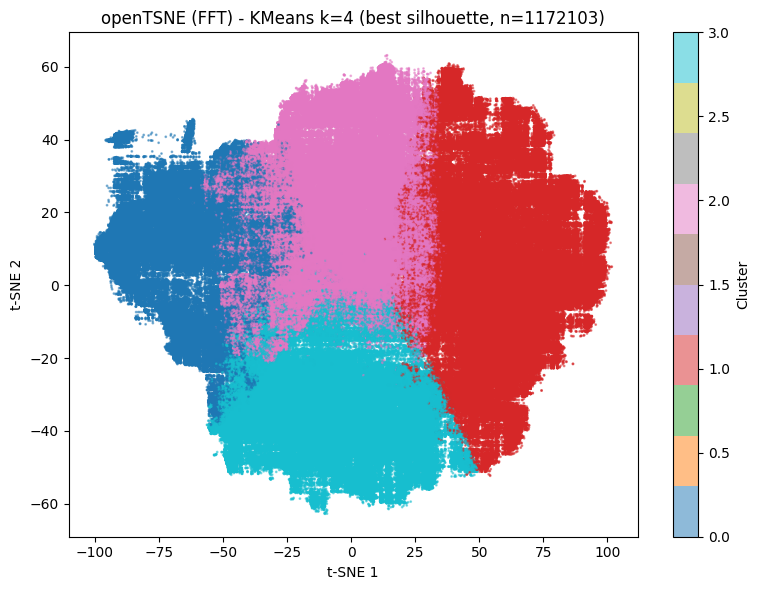

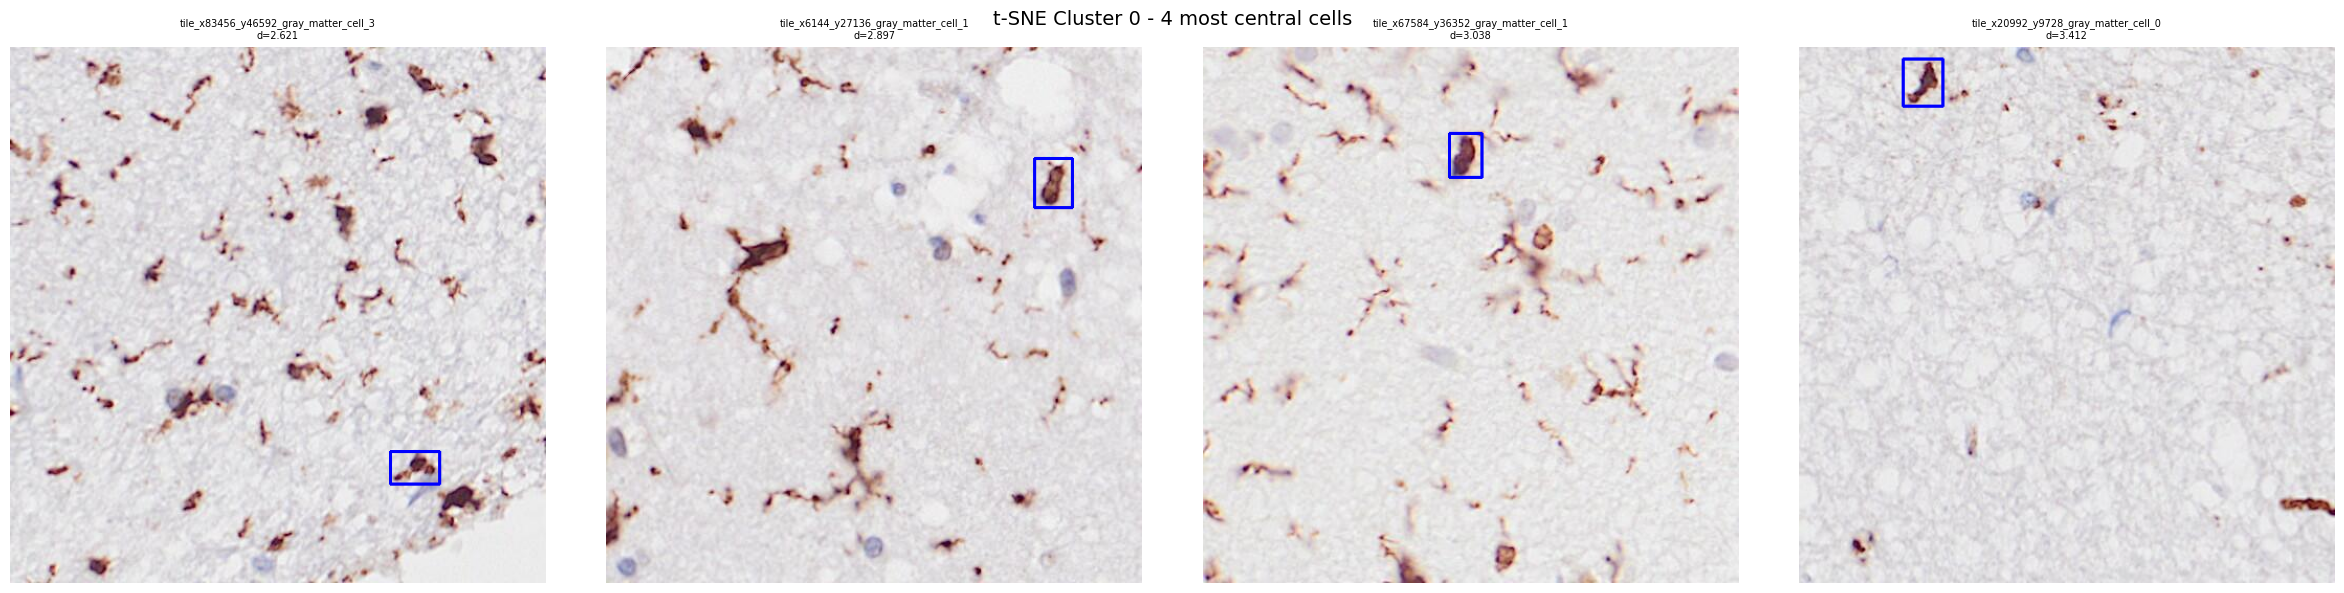

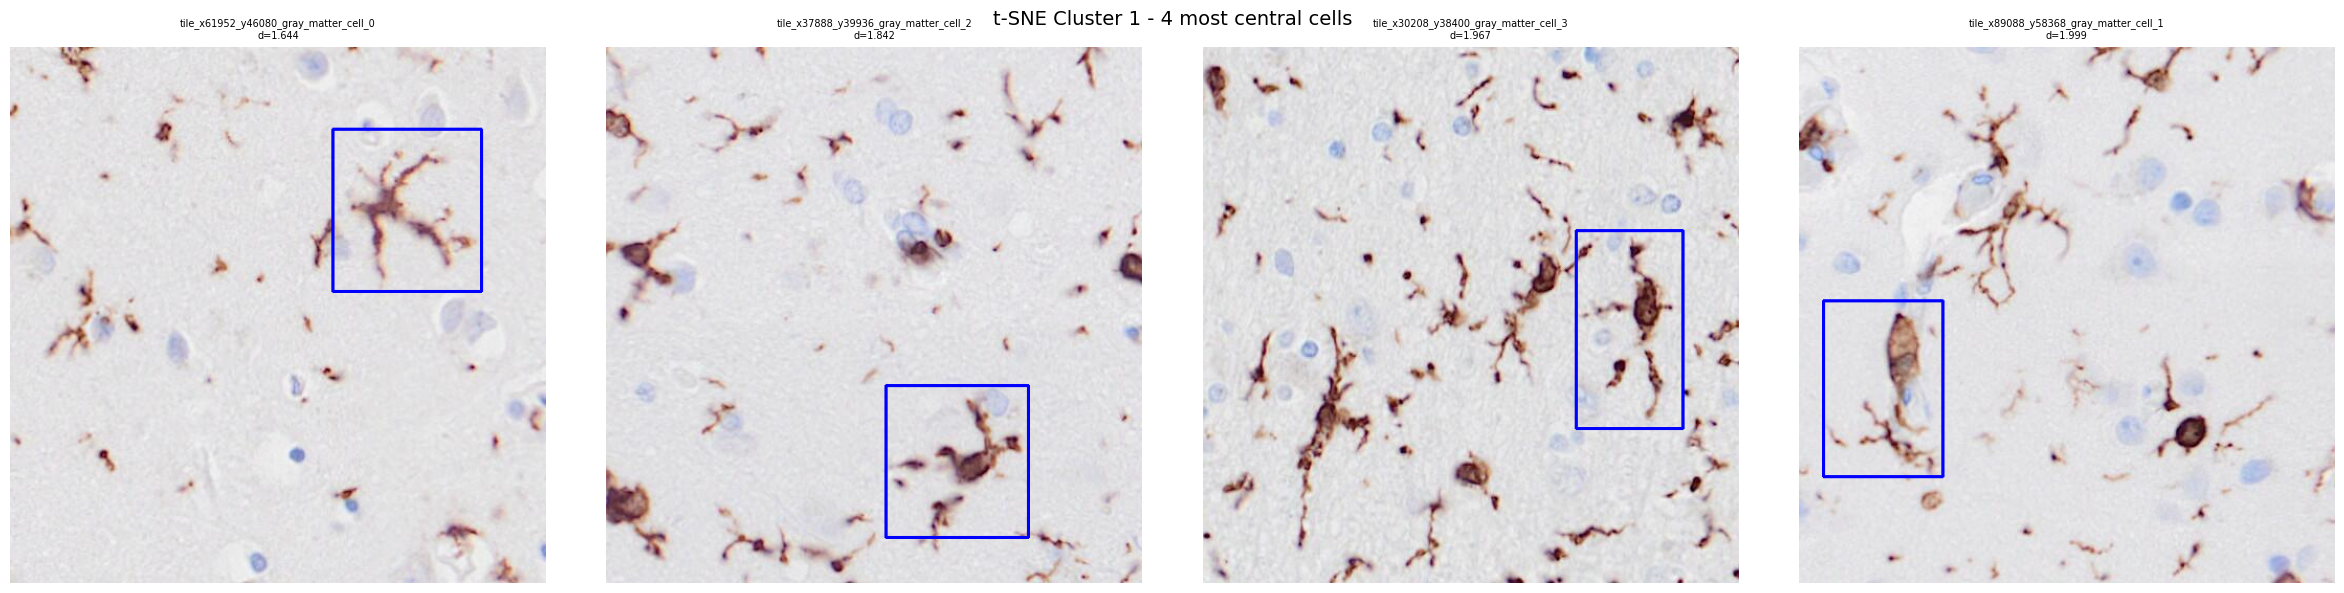

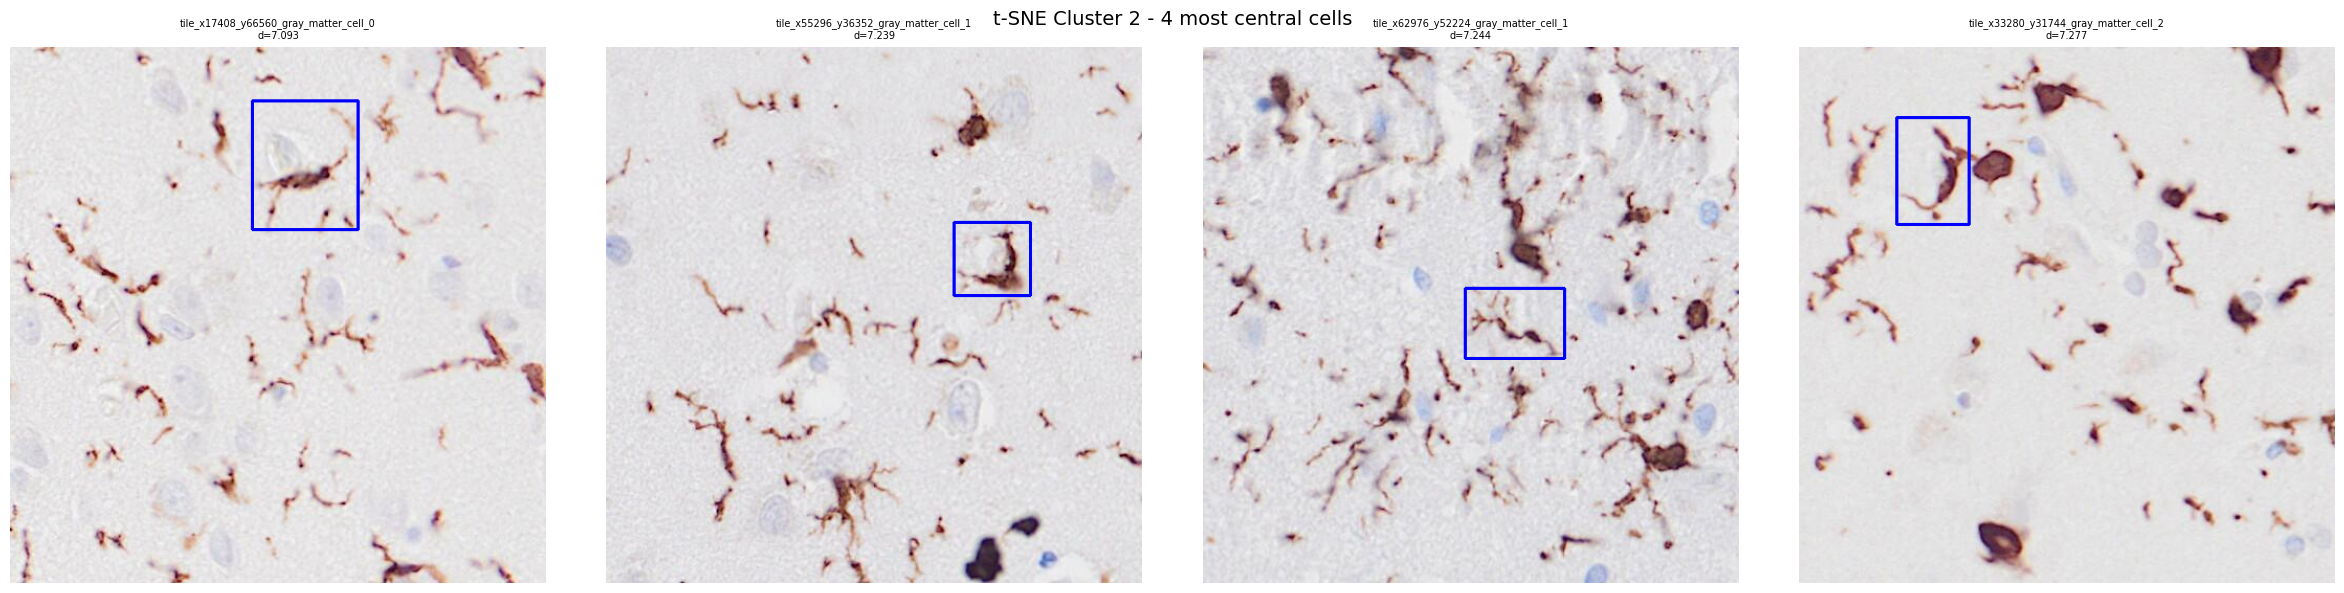

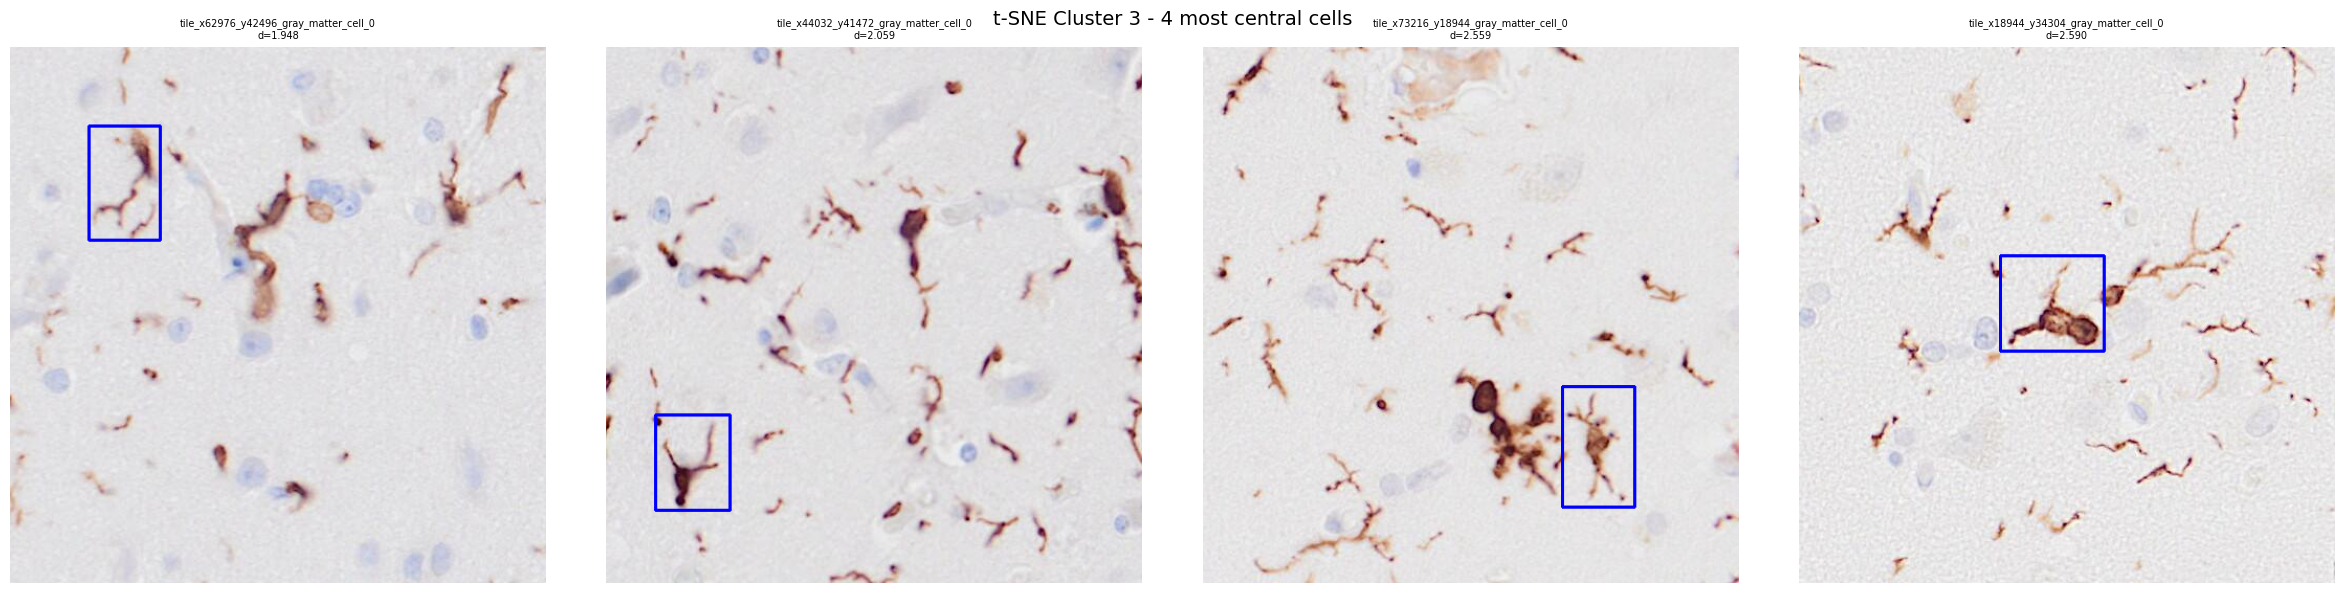

In [5]:
from sklearn.cluster import KMeans

n_clusters = 4
read_kmeans_from_csv = True
save_kmeans_to_csv = False
plot_k_means = True
kmeans_cluster_path = f"kmeans_tsne_clusters_k{n_clusters}.csv"

if read_kmeans_from_csv:
    kmeans_loaded = pd.read_csv(kmeans_cluster_path)
    tsne_fast_cluster_labels = kmeans_loaded["hard_cluster"].to_numpy(dtype=int)
    if len(tsne_fast_cluster_labels) != len(X_tsne_fast):
        raise ValueError(
            f"Loaded KMeans labels length ({len(tsne_fast_cluster_labels)}) does not match X_tsne_fast ({len(X_tsne_fast)})"
        )
    print(f"Loaded KMeans cluster labels from: {kmeans_cluster_path}")
else:
    tsne_fast_kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=42)
    tsne_fast_cluster_labels = tsne_fast_kmeans.fit_predict(X_tsne_fast)

    if save_kmeans_to_csv:
        pd.DataFrame({"hard_cluster": tsne_fast_cluster_labels}).to_csv(kmeans_cluster_path, index=False)
        print(f"Saved KMeans cluster labels to: {kmeans_cluster_path}")

if (plot_k_means):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=tsne_fast_cluster_labels, cmap='tab10', s=1, alpha=0.5)
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'openTSNE (FFT) - KMeans k={n_clusters} (best silhouette, n={len(X_tsne_fast)})')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()

    # Show representative cells for t-SNE KMeans clusters
    show_cluster_representatives(
        df_source=df,
        cluster_col='tsne_fast_cluster',
        X_feature=X_tsne_fast,
        title_prefix='t-SNE Cluster',
        scan_data_root=scan_data_root,
        n_representatives=4,
        cluster_labels_array=tsne_fast_cluster_labels,
    )


Loaded FCM soft cluster probabilities from: fcm_tsne_soft_clusters_k4.csv


C:\Users\chris\AppData\Local\Temp\ipykernel_27036\507146761.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


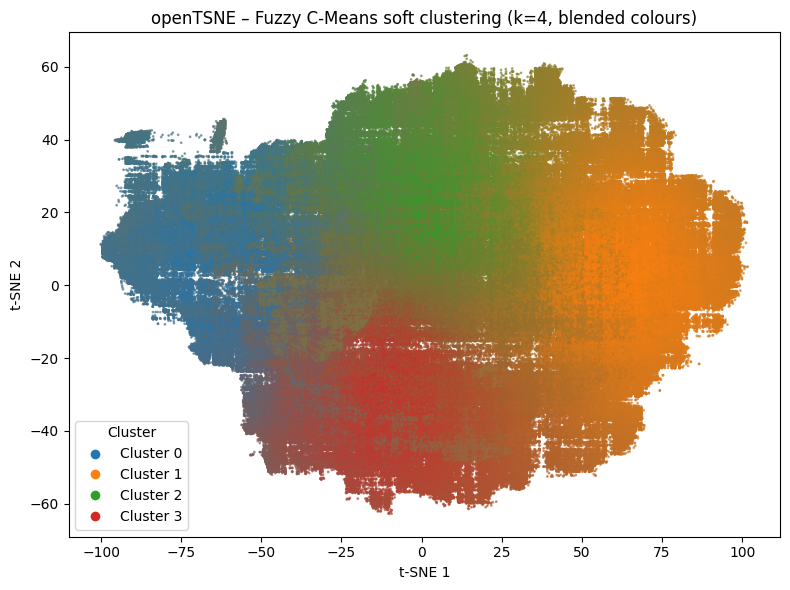

In [6]:
# --- t-SNE: Fuzzy C-Means soft clustering (blended-colour scatter) ---
# Label alignment used here:
# 0 <- 2
# 1 <- 1
# 2 <- 0
# 3 <- 3

from fcmeans import FCM
import matplotlib.cm as cm

read_fcm_from_csv = True
save_fcm_to_csv = False
plot_fcm = True

fcm_cluster_path = f"fcm_tsne_soft_clusters_k{n_clusters}.csv"

if read_fcm_from_csv:
    fcm_loaded = pd.read_csv(fcm_cluster_path)
    soft_prob_cols_loaded = [f"soft_cluster_{i}" for i in range(n_clusters)]
    missing_soft_cols = [c for c in soft_prob_cols_loaded if c not in fcm_loaded.columns]
    if missing_soft_cols:
        raise ValueError(f"Missing soft cluster columns in {fcm_cluster_path}: {missing_soft_cols}")
    fcm_tsne_probs = fcm_loaded[soft_prob_cols_loaded].to_numpy(dtype=float)
    if len(fcm_tsne_probs) != len(X_tsne_fast):
        raise ValueError(
            f"Loaded FCM probs length ({len(fcm_tsne_probs)}) does not match X_tsne_fast ({len(X_tsne_fast)})"
        )
    print(f"Loaded FCM soft cluster probabilities from: {fcm_cluster_path}")
else:
    fcm_tsne = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, error=0.005, random_state=42)
    fcm_tsne.fit(X_tsne_fast)
    # fcm_tsne.u shape: (n_samples, K)
    fcm_tsne_probs = fcm_tsne.u

    # swap 0 and 2 to align soft labels with hard-cluster convention
    fcm_tsne_probs[:, [0, 2]] = fcm_tsne_probs[:, [2, 0]]

    if save_fcm_to_csv:
        soft_prob_cols_save = [f"soft_cluster_{i}" for i in range(n_clusters)]
        pd.DataFrame(fcm_tsne_probs, columns=soft_prob_cols_save).to_csv(fcm_cluster_path, index=False)
        print(f"Saved FCM soft cluster probabilities to: {fcm_cluster_path}")


if (plot_fcm):
    cmap = cm.get_cmap('tab10')
    base_colors = np.array([cmap(i)[:3] for i in range(n_clusters)])
    blended_colors = np.clip(fcm_tsne_probs @ base_colors, 0, 1)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=blended_colors, s=1, alpha=0.6)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title(f'openTSNE – Fuzzy C-Means soft clustering (k={n_clusters}, blended colours)')
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=base_colors[i], markersize=8,
                        label=f'Cluster {i}') for i in range(n_clusters)]
    ax.legend(handles=handles, title='Cluster', loc='best')
    plt.tight_layout()
    plt.show()


## AD vs 100+: Feature Distributions and Significance

In [30]:
all_morphology_features = [
    'skeleton_length',
    'num_junctions',
    'num_components',
    'num_end_nodes',
    'num_start_nodes',
    'total_nodes',
    'end_to_start_ratio',
    'soma_area',
    'soma_perimeter',
    'soma_circularity',
    'cell_area',
    'cell_perimeter',
    'cell_convex_hull_area',
    'cell_convex_hull_perimeter',
    'cell_solidity',
    'cell_convexity',
    'cell_circularity',
    'cell_convex_circularity',
    'branch_area',
    'branch_perimeter',
    'sholl_min_radius',
    'sholl_peak_radius',
    'sholl_max_radius',
    'sholl_peak',
    'sholl_sum',
]


Add diagnosis group and inspect number of cells per scan

In [31]:
# Rebuild diagnosis labels
scan_str = df["scan_name"].astype(str)
ad_mask = (
    scan_str.str.contains("ad", case=False, regex=False, na=False)
    | scan_str.str.contains("2002-061", case=False, regex=False, na=False)
    | scan_str.str.contains("2006-060", case=False, regex=False, na=False)
)

df_analysis = df.copy()
df_analysis["diagnosis_group"] = np.where(ad_mask, "AD", "100+")

# One row per scan for scan-level counts
scan_level = df_analysis[["scan_name", "diagnosis_group"]].drop_duplicates("scan_name")

scan_group_counts = (
    scan_level.groupby("diagnosis_group")["scan_name"]
    .nunique()
    .sort_index()
)

print("Number of scans per diagnosis group:")
print(scan_group_counts.to_string())

# Cells per scan (within each diagnosis group)
cells_per_scan = (
    df_analysis.groupby(["diagnosis_group", "scan_name"])
    .size()
    .rename("n_cells")
    .reset_index()
)

# Print scan names in each group + cell counts
for g in scan_group_counts.index:
    group_scans = (
        cells_per_scan.loc[cells_per_scan["diagnosis_group"] == g, ["scan_name", "n_cells"]]
        .sort_values("scan_name")
    )
    print(f"\n=== {g} ({len(group_scans)} scans) ===")
    for _, row in group_scans.iterrows():
        print(f"{row['scan_name']} ({row['n_cells']} cells)")


Number of scans per diagnosis group:
diagnosis_group
100+    84
AD       7

=== 100+ (84 scans) ===
2014-048_Iba1_Temporal_pole_Batch_8 (14978 cells)
2016-020_Iba1_Temporal_pole_Batch_8 (13716 cells)
2016-032_Iba1_Temporal_pole_Batch_8 (3052 cells)
2017-014_Iba1_Temporal_pole_Batch_6 (11444 cells)
2017-026_Iba1_Temporal_pole_Batch_8 (9063 cells)
2017-063_Iba1_Temporal_pole_Batch_6 (10471 cells)
2017-063_Iba1_Temporal_pole_Batch_8 (6716 cells)
2017-129_Iba1_Tp_B8_100 (12209 cells)
2017-160_Iba1_Temporal_pole_Batch_6 (12209 cells)
2018-001_Iba1_Temporal_pole_Batch_6 (13252 cells)
2018-038_Iba1_Temporal_pole_Batch_6 (9605 cells)
2018-104_Iba1_Temporal_pole_Control_Batch_6 (10135 cells)
2018-104_Iba1_Tp_B8_C (13899 cells)
Image_2013-095_Temporal_pole_Iba1_Batch_4 (10691 cells)
Image_2014-037_Temporal_pole_Iba1_Batch_4 (12698 cells)
Image_2014-062_Temporal_pole_Iba1_Batch_4 (15436 cells)
Image_2015-005_Temporal_pole_Iba1_Batch_4 (14162 cells)
Image_2015-007_Temporal_pole_Iba1_Batch_4 (15897

Add additional variables from csv and get morphology feature summary per scan

In [32]:
import pandas as pd
import re
from statistical_tests import aggregate_scan_level_morphology_df

# Read cohort file
cohort_df = pd.read_csv("cohort_extra_variables.csv")

# Ensure string types for matching
df_analysis = df_analysis.copy()
df_analysis["scan_name"] = df_analysis["scan_name"].astype(str)
cohort_df["NBB"] = cohort_df["NBB"].astype(str).str.strip()

# Build matcher from NBB values (escape regex chars, longest first to avoid partial collisions)
nbb_values = cohort_df["NBB"].dropna().unique().tolist()
nbb_values = sorted(nbb_values, key=len, reverse=True)
pattern = "|".join(re.escape(v) for v in nbb_values)

# Extract the NBB that appears as a substring inside scan_name
df_analysis["NBB_match"] = df_analysis["scan_name"].str.extract(f"({pattern})", expand=False)

# Join: keep all rows from df_analysis, append all cohort columns
# (drop duplicate NBB rows in cohort if needed)
cohort_unique = cohort_df.drop_duplicates(subset=["NBB"])
df_analysis = df_analysis.merge(
    cohort_unique,
    left_on="NBB_match",
    right_on="NBB",
    how="left",
)

# Optional cleanup
df_analysis = df_analysis.drop(columns=["NBB_match"])

scan_features = [
    "Group",
    "Sex",
    "Age_at_death",
    "Thal_Aβ_stage",
    "Braak_NFT_stage",
    "CERAD_score",
    "Aβ load_total",
    "Aβ40_load",
    "Aβ42_load",
    "AT8_load",
    "pTau217_load",
    "GT38_load",
]


df_summary_per_scan = aggregate_scan_level_morphology_df(df_analysis, morphology_features = all_morphology_features, scan_features = scan_features)
# keep NBB if you want traceability; otherwise uncomment:
# df_analysis = df_analysis.drop(columns=["NBB"])

print(df_analysis.columns)
print(df_summary_per_scan.columns)


Index(['cell_id', 'skeleton_length', 'num_junctions', 'num_components',
       'num_end_nodes', 'num_start_nodes', 'total_nodes', 'end_to_start_ratio',
       'soma_area', 'soma_perimeter', 'soma_circularity', 'cell_area',
       'cell_perimeter', 'cell_convex_hull_area', 'cell_convex_hull_perimeter',
       'cell_solidity', 'cell_convexity', 'cell_circularity',
       'cell_convex_circularity', 'branch_area', 'branch_perimeter',
       'sholl_min_radius', 'sholl_peak_radius', 'sholl_max_radius',
       'sholl_peak', 'sholl_sum', 'xmin', 'ymin', 'xmax', 'ymax', 'image_name',
       'scan_name', 'global_cell_id', 'diagnosis_group', 'NBB', 'Group', 'Sex',
       'Age_at_death', 'Thal_Aβ_stage', 'Braak_NFT_stage', 'CERAD_score',
       'Aβ load_total', 'Aβ40_load', 'Aβ42_load', 'AT8_load', 'pTau217_load',
       'GT38_load'],
      dtype='object')
Index(['scan_name', 'skeleton_length', 'num_junctions', 'num_components',
       'num_end_nodes', 'num_start_nodes', 'total_nodes', 'end_to_sta

In [33]:
# Derive NIA-AA Table 3 AD intensity per scan and split 100+ scans by pathology.
def _max_stage_from_text(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    matches = re.findall(r"\d+(?:\.\d+)?", str(value))
    if not matches:
        return np.nan
    return max(float(m) for m in matches)

def _thal_to_a_score(thal_value):
    if pd.isna(thal_value):
        return np.nan
    if thal_value <= 0:
        return 'A0'
    if thal_value <= 2:
        return 'A1'
    if thal_value <= 3:
        return 'A2'
    return 'A3'

def _braak_to_b_score(braak_value):
    if pd.isna(braak_value):
        return np.nan
    if braak_value <= 0:
        return 'B0'
    if braak_value <= 2:
        return 'B1'
    if braak_value <= 4:
        return 'B2'
    return 'B3'

def _cerad_to_c_score(cerad_value):
    if pd.isna(cerad_value):
        return np.nan
    if cerad_value <= 0:
        return 'C0'
    if cerad_value <= 1:
        return 'C1'
    if cerad_value <= 2:
        return 'C2'
    return 'C3'

def _nia_aa_ad_intensity(a_score, b_score, c_score):
    if pd.isna(a_score) or pd.isna(b_score) or pd.isna(c_score):
        return np.nan

    if a_score == 'A0' and c_score == 'C0':
        return 'Not'

    if a_score == 'A1' and c_score in {'C0', 'C1'}:
        return 'Low'

    if a_score == 'A1' and c_score in {'C2', 'C3'}:
        return 'Low' if b_score in {'B0', 'B1'} else 'Intermediate'

    if a_score == 'A2':
        return 'Low' if b_score in {'B0', 'B1'} else 'Intermediate'

    if a_score == 'A3' and c_score in {'C0', 'C1'}:
        return 'Low' if b_score in {'B0', 'B1'} else 'Intermediate'

    if a_score == 'A3' and c_score in {'C2', 'C3'}:
        if b_score in {'B0', 'B1'}:
            return 'Low'
        if b_score == 'B2':
            return 'Intermediate'
        if b_score == 'B3':
            return 'High'

    return np.nan

scan_pathology = (
    df_analysis[['scan_name', 'diagnosis_group', 'Thal_Aβ_stage', 'Braak_NFT_stage', 'CERAD_score']]
    .drop_duplicates('scan_name')
    .copy()
)

scan_pathology['Thal_Aβ_stage_numeric'] = scan_pathology['Thal_Aβ_stage'].apply(_max_stage_from_text)
scan_pathology['Braak_NFT_stage_numeric'] = pd.to_numeric(scan_pathology['Braak_NFT_stage'], errors='coerce')
scan_pathology['CERAD_score_numeric'] = pd.to_numeric(scan_pathology['CERAD_score'], errors='coerce')

scan_pathology['A_score'] = scan_pathology['Thal_Aβ_stage_numeric'].apply(_thal_to_a_score)
scan_pathology['B_score'] = scan_pathology['Braak_NFT_stage_numeric'].apply(_braak_to_b_score)
scan_pathology['C_score'] = scan_pathology['CERAD_score_numeric'].apply(_cerad_to_c_score)
scan_pathology['ABC_score'] = (
    scan_pathology['A_score'].fillna('NA')
    + ', ' + scan_pathology['B_score'].fillna('NA')
    + ', ' + scan_pathology['C_score'].fillna('NA')
)
scan_pathology['AD_intensity_score'] = scan_pathology.apply(
    lambda row: _nia_aa_ad_intensity(row['A_score'], row['B_score'], row['C_score']),
    axis=1,
)

scan_pathology['diagnosis_group_binary'] = scan_pathology['diagnosis_group']
scan_pathology['diagnosis_group_pathology'] = scan_pathology['diagnosis_group_binary']
centenarian_mask = scan_pathology['diagnosis_group_binary'].eq('100+')
pathology_positive_mask = scan_pathology['AD_intensity_score'].isin(['High', 'Intermediate'])
scan_pathology.loc[centenarian_mask & pathology_positive_mask, 'diagnosis_group_pathology'] = '100+_with_pathology'
scan_pathology.loc[centenarian_mask & ~pathology_positive_mask, 'diagnosis_group_pathology'] = '100+_without_pathology'

new_scan_cols = [
    'A_score',
    'B_score',
    'C_score',
    'ABC_score',
    'AD_intensity_score',
    'diagnosis_group_binary',
    'diagnosis_group_pathology',
]
df_analysis = df_analysis.drop(columns=[c for c in new_scan_cols if c in df_analysis.columns])
df_analysis = df_analysis.merge(
    scan_pathology[['scan_name'] + new_scan_cols],
    on='scan_name',
    how='left',
)

for extra_scan_feature in ['diagnosis_group_binary', 'diagnosis_group_pathology', 'A_score', 'B_score', 'C_score', 'ABC_score', 'AD_intensity_score']:
    if extra_scan_feature not in scan_features:
        scan_features.append(extra_scan_feature)

df_summary_per_scan = aggregate_scan_level_morphology_df(
    df_analysis,
    morphology_features=all_morphology_features,
    scan_features=scan_features,
)

if 'final_cluster_props_df' in globals():
    df_scan_full = df_summary_per_scan.merge(
        final_cluster_props_df,
        on='scan_name',
        how='inner',
        suffixes=('_summary', '_cluster'),
    )
    if {'diagnosis_group_summary', 'diagnosis_group_cluster'}.issubset(df_scan_full.columns):
        mismatch_mask = (
            df_scan_full['diagnosis_group_summary'].notna()
            & df_scan_full['diagnosis_group_cluster'].notna()
            & (df_scan_full['diagnosis_group_summary'] != df_scan_full['diagnosis_group_cluster'])
        )
        if mismatch_mask.any():
            print(f"Warning: diagnosis_group mismatch in {mismatch_mask.sum()} scans after merge.")
        df_scan_full['diagnosis_group'] = df_scan_full['diagnosis_group_summary'].combine_first(df_scan_full['diagnosis_group_cluster'])
        df_scan_full = df_scan_full.drop(columns=['diagnosis_group_summary', 'diagnosis_group_cluster'])

group_order = ['AD', '100+_with_pathology', '100+_without_pathology']
scan_group_counts = (
    scan_pathology['diagnosis_group_pathology']
    .value_counts()
    .reindex(group_order, fill_value=0)
)

print('Number of scans per pathology-aware diagnosis group:')
print(scan_group_counts.to_string())

print('\nCentenarian scans by AD intensity score:')
print(
    scan_pathology.loc[centenarian_mask, 'AD_intensity_score']
    .fillna('Missing')
    .value_counts()
    .sort_index()
    .to_string()
)


Number of scans per pathology-aware diagnosis group:
diagnosis_group_pathology
AD                         7
100+_with_pathology       39
100+_without_pathology    45

Centenarian scans by AD intensity score:
AD_intensity_score
High             4
Intermediate    35
Low             40
Not              5


## Basic Analysis of Scan Extra Variables

=== Correlation: numeric scan features vs numeric scan features ===
                 Age_at_death  Thal_Aβ_stage  Braak_NFT_stage  CERAD_score  Aβ load_total  Aβ40_load  Aβ42_load  AT8_load  pTau217_load  GT38_load
Age_at_death         1.000000       0.091319        -0.217014    -0.149781      -0.103030  -0.139380  -0.132773 -0.122869     -0.083430  -0.132693
Thal_Aβ_stage        0.091319       1.000000         0.409036     0.834836       0.822819   0.817520   0.819227  0.560587      0.516457   0.425665
Braak_NFT_stage     -0.217014       0.409036         1.000000     0.566228       0.464517   0.555129   0.541165  0.666608      0.656768   0.627416
CERAD_score         -0.149781       0.834836         0.566228     1.000000       0.743200   0.811506   0.810717  0.636816      0.608945   0.505059
Aβ load_total       -0.103030       0.822819         0.464517     0.743200       1.000000   0.821990   0.779104  0.565699      0.563379   0.477705
Aβ40_load           -0.139380       0.817520      

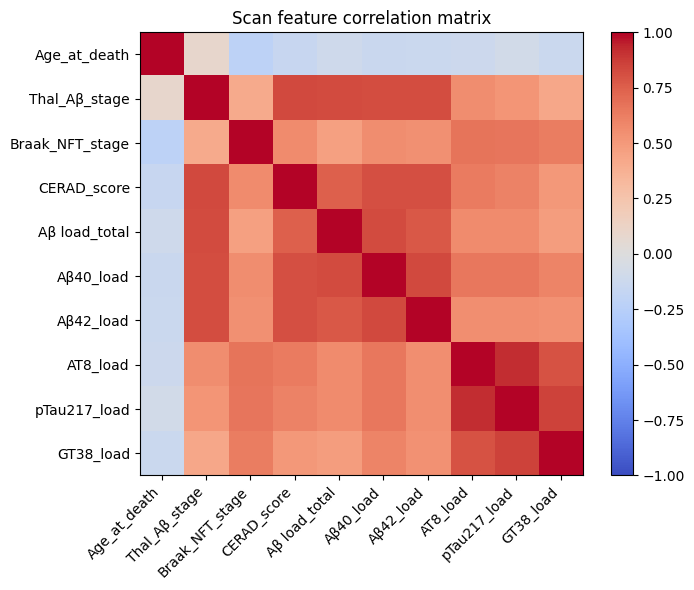

=== Correlation: numeric scan features vs morphology features ===
                 skeleton_length  num_junctions  num_components  num_end_nodes  num_start_nodes  total_nodes  end_to_start_ratio  soma_area  soma_perimeter  soma_circularity  cell_area  cell_perimeter  cell_convex_hull_area  cell_convex_hull_perimeter  cell_solidity  cell_convexity  cell_circularity  cell_convex_circularity  branch_area  branch_perimeter  sholl_min_radius  sholl_peak_radius  sholl_max_radius  sholl_peak  sholl_sum
Age_at_death            0.022934      -0.025586        0.029697       0.016951         0.006540     0.012299            0.024638  -0.099072       -0.058549         -0.046903  -0.044107        0.040021               0.049524                    0.053324      -0.041367        0.025610         -0.046959                -0.043478    -0.059194          0.022217         -0.130234           0.009758          0.031194   -0.022854   0.022934
Thal_Aβ_stage           0.001550       0.035484        0.002741 

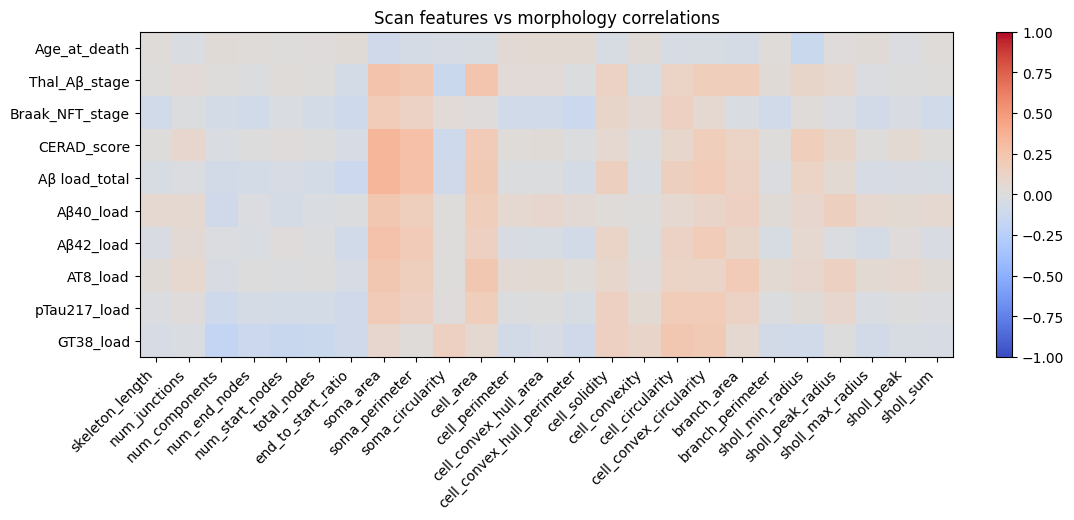

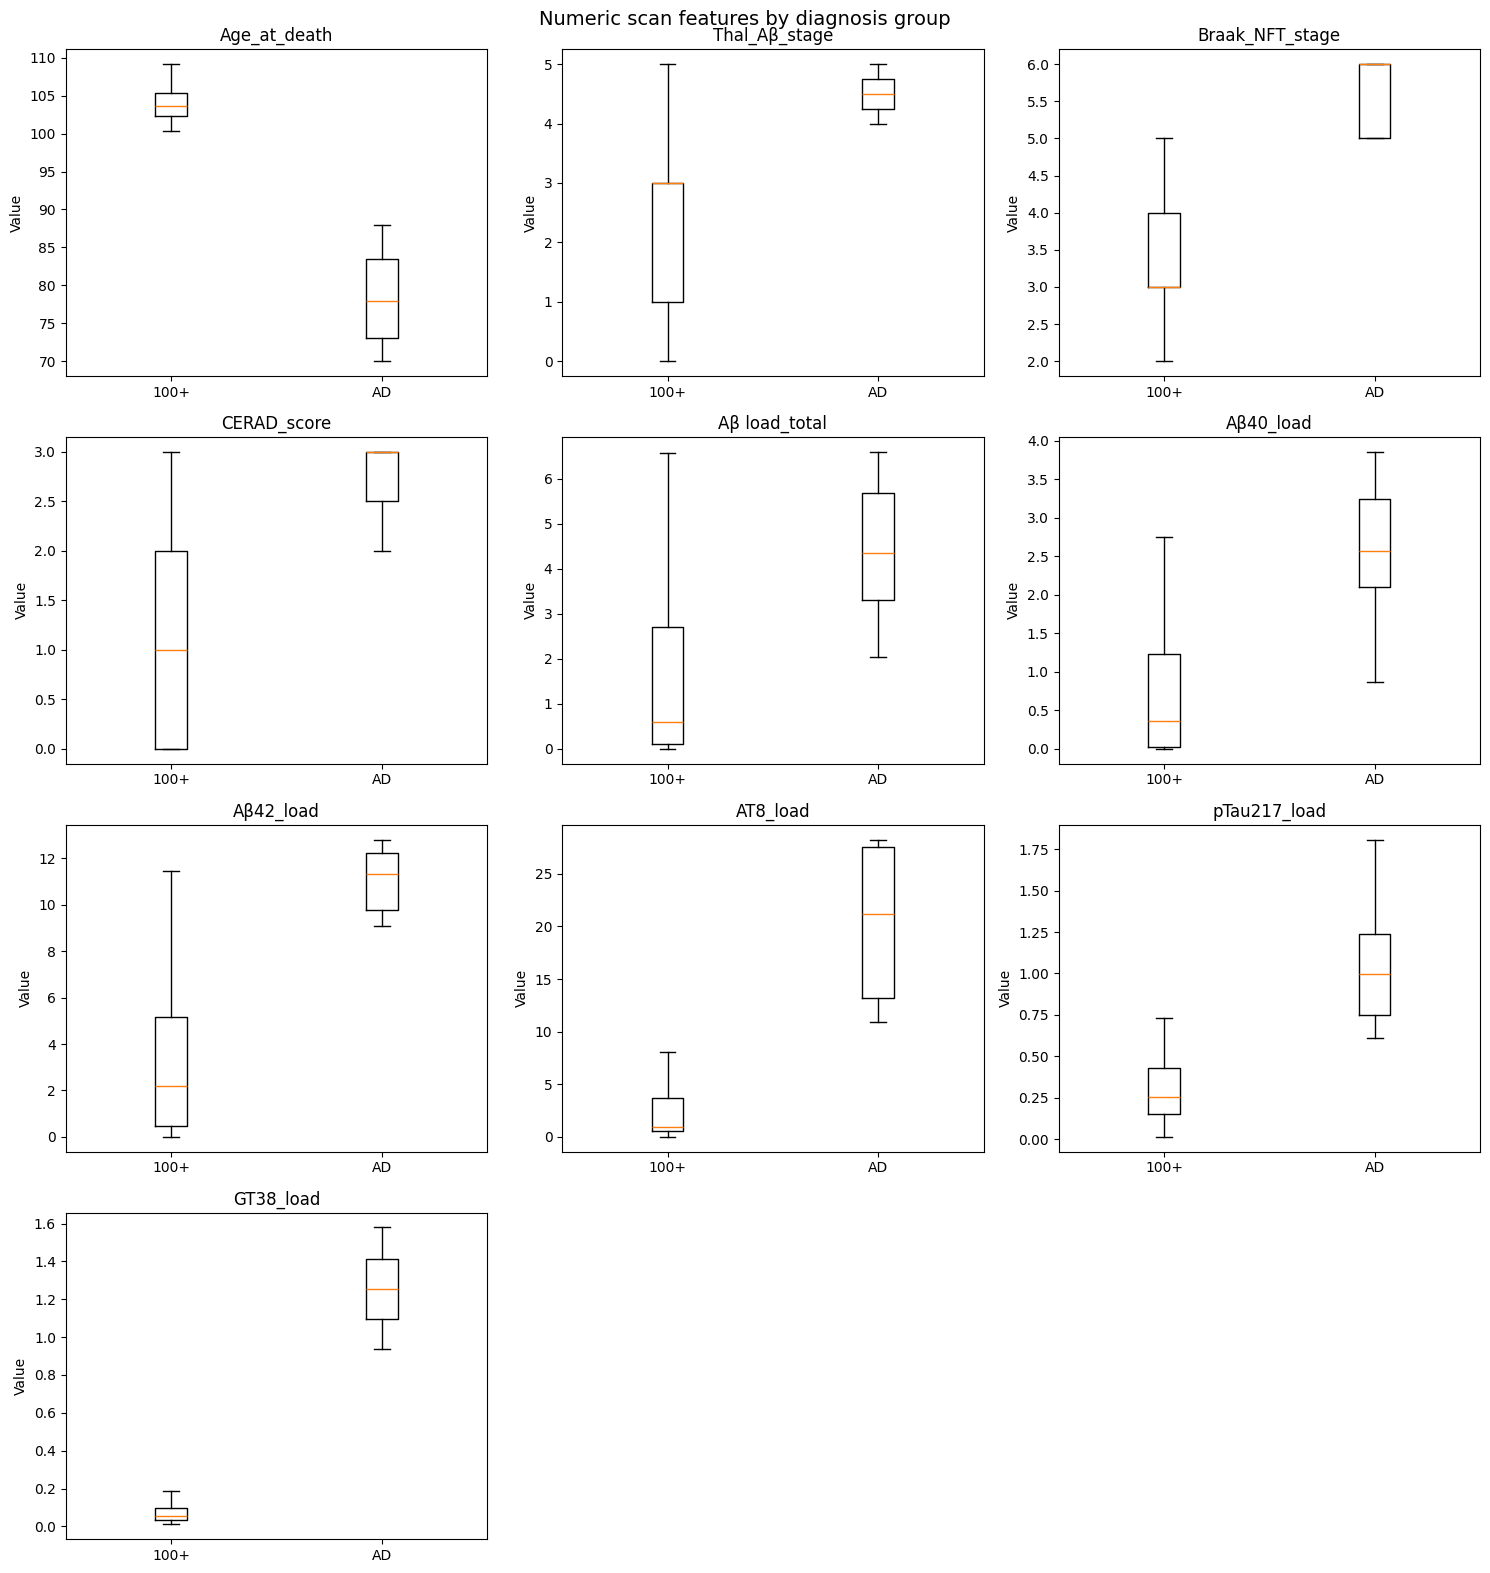

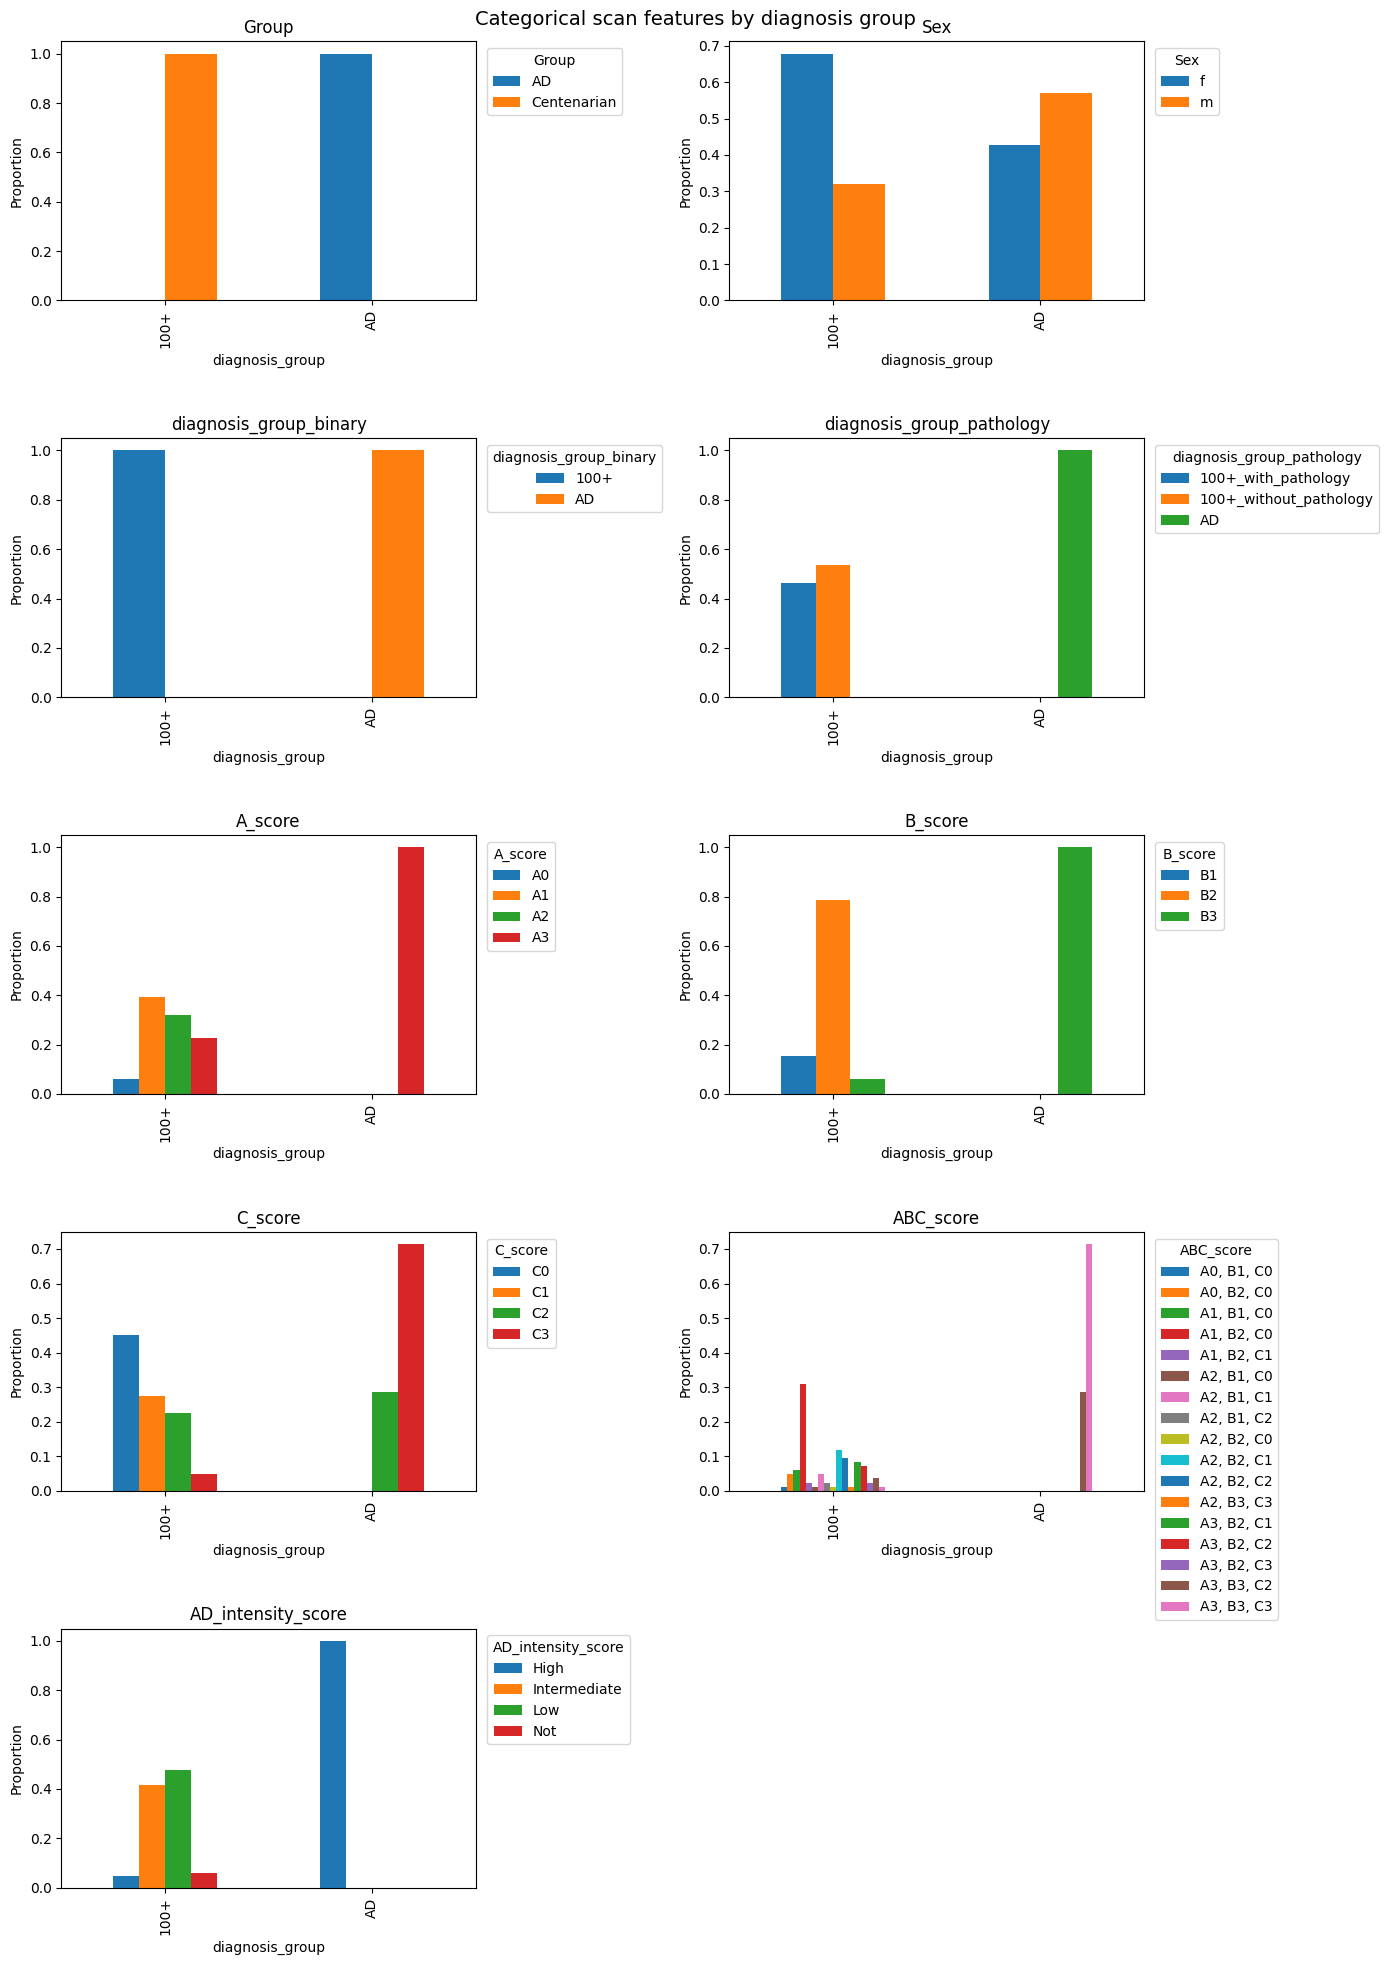

In [34]:
from extra_variables_analysis import run_basic_extra_variables_analysis

extra_vars_analysis_results = run_basic_extra_variables_analysis(
    df_summary_per_scan=df_summary_per_scan,
    scan_features=scan_features,
    morphology_features=all_morphology_features,
    diagnosis_col="diagnosis_group",
    corr_method="spearman",
)


Basic Mann whitneyu (Not accounting for scans)

=== AD vs 100+ per-feature significance (Mann-Whitney U) ===
                   feature  n_AD  n_100+   median_AD  median_100+  p_value_mannwhitney
               branch_area 73877 1098226  765.000000   689.000000        7.822419e-254
                 cell_area 73877 1098226 1262.000000  1188.000000        9.482777e-198
          soma_circularity 73877 1098226    0.834034     0.817884        6.148743e-174
             cell_solidity 73877 1098226    0.428864     0.401696        1.367959e-115
             num_junctions 73877 1098226    2.000000     2.000000         7.660937e-78
                sholl_peak 73877 1098226    7.000000     7.000000         2.415675e-76
          cell_circularity 73877 1098226    0.154698     0.144386         5.551932e-68
   cell_convex_circularity 73877 1098226    0.763828     0.757634         1.095417e-47
            soma_perimeter 73877 1098226   89.112698    90.426406         1.419664e-45
          sholl_min_radius 73877 1098226   12.000000    12.000000    

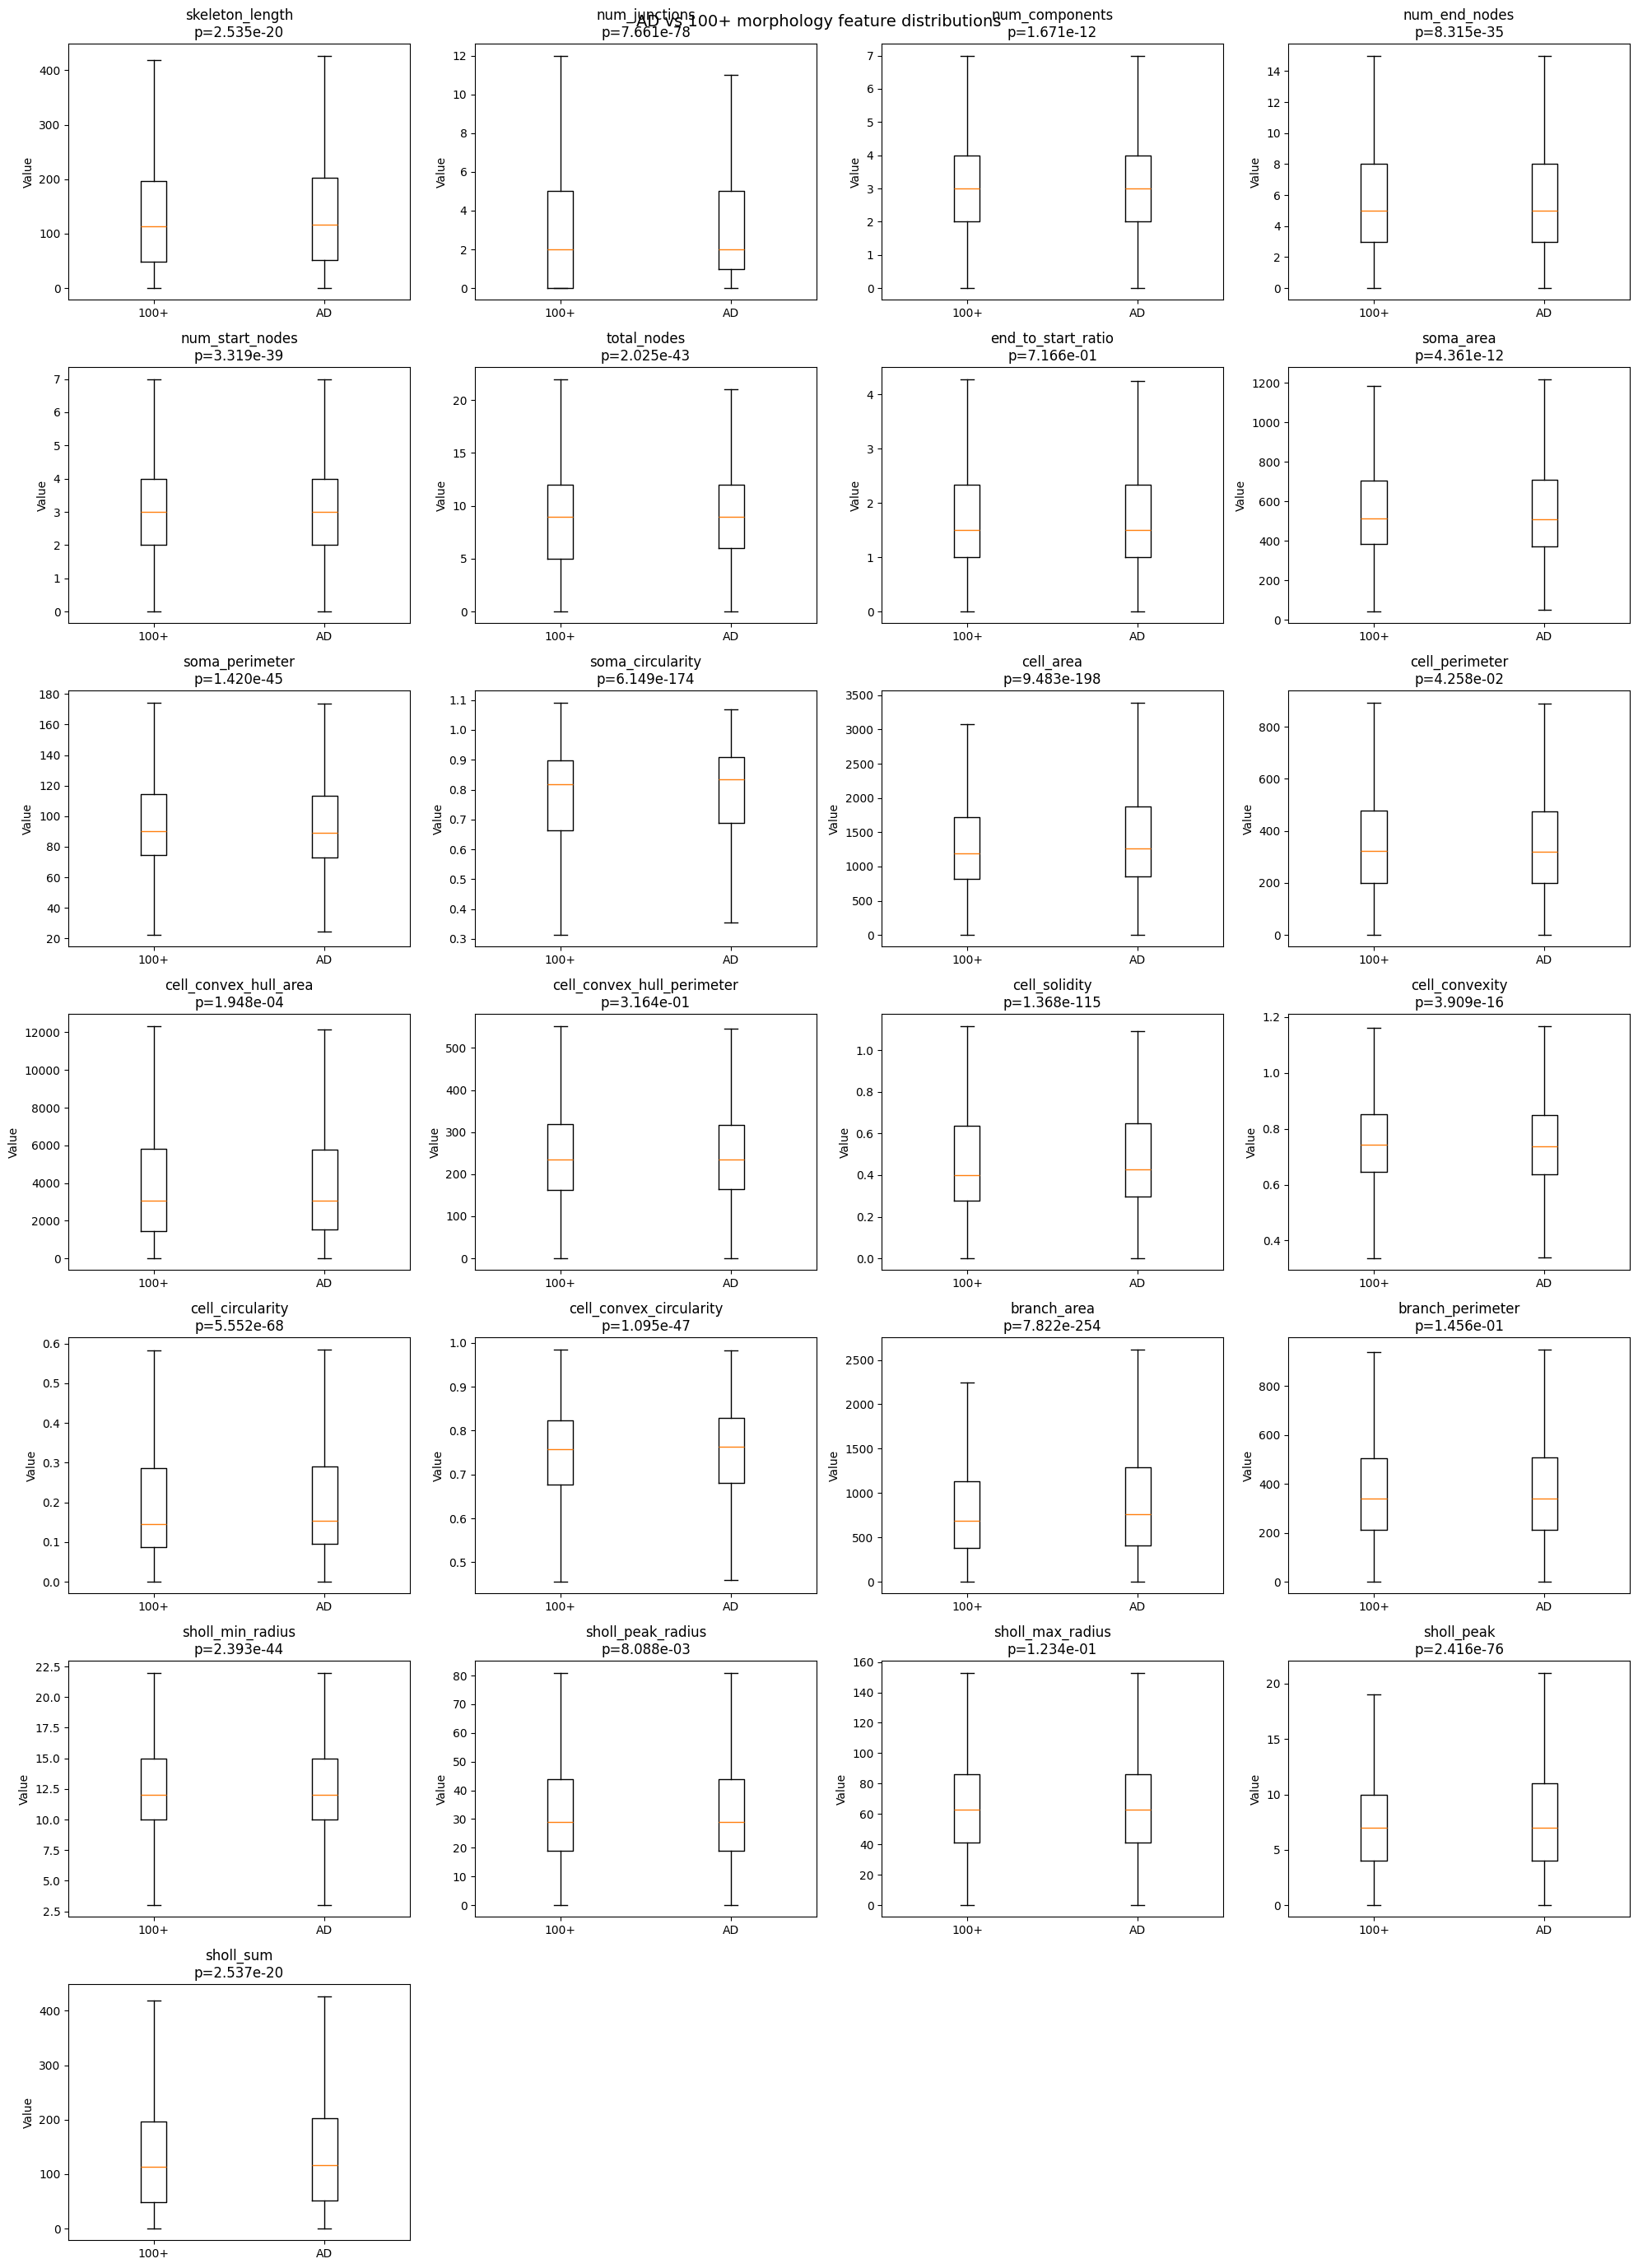

In [35]:
from scipy.stats import mannwhitneyu


numeric_features = [f for f in all_morphology_features if f in df_analysis.columns]

stats_rows = []
for feature in numeric_features:
    ad_vals = df_analysis.loc[df_analysis['diagnosis_group'] == 'AD', feature].dropna()
    c100_vals = df_analysis.loc[df_analysis['diagnosis_group'] == '100+', feature].dropna()

    if len(ad_vals) > 0 and len(c100_vals) > 0:
        _, p_val = mannwhitneyu(ad_vals, c100_vals, alternative='two-sided')
    else:
        p_val = np.nan

    stats_rows.append({
        'feature': feature,
        'n_AD': int(len(ad_vals)),
        'n_100+': int(len(c100_vals)),
        'median_AD': float(ad_vals.median()) if len(ad_vals) else np.nan,
        'median_100+': float(c100_vals.median()) if len(c100_vals) else np.nan,
        'p_value_mannwhitney': float(p_val) if pd.notna(p_val) else np.nan,
    })

feature_stats_df = pd.DataFrame(stats_rows).sort_values('p_value_mannwhitney')
print('=== AD vs 100+ per-feature significance (Mann-Whitney U) ===')
print(feature_stats_df.to_string(index=False))


# Plot box plots for morphological features by diagnosis group
n_features = len(numeric_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, feature in enumerate(numeric_features):
    ax = axes[i]
    ad_vals = df_analysis.loc[df_analysis['diagnosis_group'] == 'AD', feature].dropna()
    c100_vals = df_analysis.loc[df_analysis['diagnosis_group'] == '100+', feature].dropna()

    ax.boxplot([c100_vals, ad_vals], tick_labels=['100+', 'AD'], showfliers=False)
    p_val = feature_stats_df.loc[feature_stats_df['feature'] == feature, 'p_value_mannwhitney'].iloc[0]
    ax.set_title(f"{feature}\np={p_val:.3e}")
    ax.set_ylabel('Value')

for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('AD vs 100+ morphology feature distributions', fontsize=14)
plt.tight_layout()
plt.show()


Mixed effect modelling

In [36]:
from statistical_tests import mixed_effect_morphology_feature_tests

# morphology_features = [
#     'soma_area', 
#     'skeleton_length', 
#     'cell_area', 
#     'cell_convexity'
# ]



mixed_feature_stats_df = mixed_effect_morphology_feature_tests(
    df_analysis=df_analysis,
    # morphology_features=morphology_features,   # reuse your existing list
    diagnosis_col="diagnosis_group",
    scan_col="scan_name",
    group_a="AD",
    group_b="100+",
    max_cells_per_scan=None,   # keeps runtime manageable; set None to use all cells
    random_state=42,
    apply_fdr=True, 
    scan_features = ['Sex']
)




Selected representative morphology features (scan-level correlation clustering):
['cell_convex_circularity', 'num_components', 'sholl_min_radius', 'sholl_sum', 'soma_perimeter']
=== Scan-level feature test (diagnosis adjusted for scan_features) ===
Scan-level dataframe shape: (91, 8)
Interpretation: coef > 0 means higher values in AD than 100+ after adjusting for scan_features: ['Sex'].
                feature  n_scans  coef_AD_minus_100+        se    z_stat  p_value    ci_2.5%  ci_97.5%  converged  q_value_fdr_bh
       sholl_min_radius       91            0.736622  0.355555  2.071752 0.041216   0.039734  1.433509      False        0.206079
cell_convex_circularity       91           -0.005217  0.006025 -0.865889 0.388906  -0.017025  0.006592      False        0.790848
         num_components       91           -0.071571  0.173455 -0.412623 0.680887  -0.411543  0.268400      False        0.790848
              sholl_sum       91           -3.046328 10.819113 -0.281569 0.778935 -24.2517

Pairwise mixed effect modelling using pathology-aware diagnosis groups

In [37]:
pairwise_group_comparisons = [
    ('AD', '100+_with_pathology'),
    ('AD', '100+_without_pathology'),
    ('100+_with_pathology', '100+_without_pathology'),
]

pairwise_mixed_effect_results = {}
for group_a, group_b in pairwise_group_comparisons:
    print(f'\n===== Mixed effect modelling: {group_a} vs {group_b} =====')
    pairwise_mixed_effect_results[(group_a, group_b)] = mixed_effect_morphology_feature_tests(
        df_analysis=df_analysis,
        diagnosis_col='diagnosis_group_pathology',
        scan_col='scan_name',
        group_a=group_a,
        group_b=group_b,
        max_cells_per_scan=None,
        random_state=42,
        apply_fdr=True,
        scan_features=['Sex'],
    )



===== Mixed effect modelling: AD vs 100+_with_pathology =====
Selected representative morphology features (scan-level correlation clustering):
['cell_convex_circularity', 'num_components', 'sholl_min_radius', 'sholl_sum', 'soma_perimeter']
=== Scan-level feature test (diagnosis adjusted for scan_features) ===
Scan-level dataframe shape: (46, 8)
Interpretation: coef > 0 means higher values in AD than 100+_with_pathology after adjusting for scan_features: ['Sex'].
                feature  n_scans  coef_AD_minus_100+_with_pathology       se    z_stat  p_value    ci_2.5%  ci_97.5%  converged  q_value_fdr_bh
cell_convex_circularity       46                          -0.005441 0.006082 -0.894556 0.376005  -0.017362  0.006480      False        0.523926
         num_components       46                          -0.129700 0.158995 -0.815747 0.419141  -0.441329  0.181930      False        0.523926
       sholl_min_radius       46                           0.432173 0.314043  1.376158 0.175898  -0.

In [38]:
from statistical_tests import permanova_morphology_feature_tests

permanova_out = permanova_morphology_feature_tests(
    df_analysis=df_analysis,
    morphology_features=None,              # auto-select representative set if None
    scan_features=["Sex"],                 # kept in scan-level df
    diagnosis_col="diagnosis_group",
    scan_col="scan_name",
    group_a="AD",
    group_b="100+",
    random_state=42,
    remove_small_scans=False,
    # min_cells_per_scan_for_inclusion=5000,  # or None for bottom 10%
    n_permutations=5000,
)


Selected representative morphology features for PERMANOVA:
['cell_convex_circularity', 'num_components', 'sholl_min_radius', 'sholl_sum', 'soma_perimeter']
=== PERMANOVA (scan-level morphology profiles) ===
 n_scans  n_scans_AD  n_scans_100+  n_features  pseudo_F       r2  p_value_permutation  n_permutations
      91           7            84           5  0.944116 0.010497             0.302939            5000


Pairwise PERMANOVA using pathology-aware diagnosis groups

In [39]:
pairwise_permanova_results = {}
for group_a, group_b in pairwise_group_comparisons:
    print(f'\n===== PERMANOVA: {group_a} vs {group_b} =====')
    pairwise_permanova_results[(group_a, group_b)] = permanova_morphology_feature_tests(
        df_analysis=df_analysis,
        morphology_features=None,
        scan_features=['Sex'],
        diagnosis_col='diagnosis_group_pathology',
        scan_col='scan_name',
        group_a=group_a,
        group_b=group_b,
        random_state=42,
        remove_small_scans=False,
        n_permutations=5000,
    )



===== PERMANOVA: AD vs 100+_with_pathology =====
Selected representative morphology features for PERMANOVA:
['cell_convex_circularity', 'num_components', 'sholl_min_radius', 'sholl_sum', 'soma_perimeter']
=== PERMANOVA (scan-level morphology profiles) ===
 n_scans  n_scans_AD  n_scans_100+_with_pathology  n_features  pseudo_F       r2  p_value_permutation  n_permutations
      46           7                           39           5  1.293857 0.028566             0.279344            5000

===== PERMANOVA: AD vs 100+_without_pathology =====
Selected representative morphology features for PERMANOVA:
['cell_convex_circularity', 'cell_perimeter', 'sholl_min_radius', 'soma_area', 'soma_circularity']
=== PERMANOVA (scan-level morphology profiles) ===
 n_scans  n_scans_AD  n_scans_100+_without_pathology  n_features  pseudo_F       r2  p_value_permutation  n_permutations
      52           7                              45           5  1.634851 0.031662             0.209558            5000

==

## AD vs 100+: Per-scan Cluster Proportions (Hard and Soft)

In [40]:
import numpy as np
import pandas as pd

# Base table (one row per cell)
df_clustered = df_analysis.copy()
df_clustered["diagnosis_group_pathology"] = df_analysis["diagnosis_group_pathology"].values
df_clustered["hard_cluster"] = tsne_fast_cluster_labels

# Safety check: soft memberships must align row-wise with df_clustered
assert len(df_clustered) == fcm_tsne_probs.shape[0], "Row count mismatch between df_clustered and fcm_tsne_probs"

# -----------------------------
# HARD CLUSTERS: per-scan proportions
# -----------------------------
hard_counts_df = (
    df_clustered
    .groupby(["diagnosis_group_pathology", "scan_name", "hard_cluster"], as_index=False)
    .size()
    .pivot(index=["diagnosis_group_pathology", "scan_name"], columns="hard_cluster", values="size")
    .fillna(0)
    .reset_index()
)

hard_counts_df = hard_counts_df.rename(
    columns=lambda c: f"hard_cluster_{int(c)}" if isinstance(c, (int, np.integer)) else c
)
hard_counts_df.columns.name = None

hard_cols = sorted(
    [c for c in hard_counts_df.columns if c.startswith("hard_cluster_")],
    key=lambda x: int(x.split("_")[-1])
)

hard_counts_df[hard_cols] = hard_counts_df[hard_cols].astype(float)

# Total cells per scan (from hard counts)
hard_counts_df["n_cells"] = hard_counts_df[hard_cols].sum(axis=1).astype(int)

hard_props_df = hard_counts_df[["diagnosis_group_pathology", "scan_name", "n_cells"] + hard_cols].copy()
hard_props_df[hard_cols] = hard_props_df[hard_cols].div(hard_counts_df["n_cells"], axis=0)

# -----------------------------
# SOFT CLUSTERS: per-scan mean memberships
# -----------------------------
soft_cols = [f"soft_cluster_{i}" for i in range(fcm_tsne_probs.shape[1])]

soft_cell_df = pd.DataFrame(fcm_tsne_probs, columns=soft_cols, index=df_clustered.index)
soft_cell_df["scan_name"] = df_clustered["scan_name"].values
soft_cell_df["diagnosis_group_pathology"] = df_clustered["diagnosis_group_pathology"].values

soft_props_df = (
    soft_cell_df
    .groupby(["diagnosis_group_pathology", "scan_name"], as_index=False)[soft_cols]
    .mean()
)

# -----------------------------
# Cluster proportions per scan
# -----------------------------
final_cluster_props_df = hard_props_df.merge(
    soft_props_df,
    on=["diagnosis_group_pathology", "scan_name"],
    how="inner"
)
scan_group_labels = df_clustered[["scan_name", "diagnosis_group", "diagnosis_group_pathology"]].drop_duplicates("scan_name")
final_cluster_props_df = final_cluster_props_df.merge(
    scan_group_labels,
    on=["scan_name", "diagnosis_group_pathology"],
    how="left"
)

final_cols = ["scan_name", "diagnosis_group", "diagnosis_group_pathology", "n_cells"] + hard_cols + soft_cols
final_cluster_props_df = final_cluster_props_df[final_cols]

print(final_cluster_props_df.head(2))

# -----------------------------
# Join with df_summary_per_scan
# -> one row per scan with:
#    scan features + mean morphology + cluster proportions
# -----------------------------
df_scan_full = df_summary_per_scan.merge(
    final_cluster_props_df,
    on="scan_name",
    how="inner",
    suffixes=("_summary", "_cluster"),
)

# If diagnosis_group exists in both, keep one and check consistency
if {"diagnosis_group_summary", "diagnosis_group_cluster"}.issubset(df_scan_full.columns):
    mismatch_mask = (
        df_scan_full["diagnosis_group_summary"].notna()
        & df_scan_full["diagnosis_group_cluster"].notna()
        & (df_scan_full["diagnosis_group_summary"] != df_scan_full["diagnosis_group_cluster"])
    )
    if mismatch_mask.any():
        print(f"Warning: diagnosis_group mismatch in {mismatch_mask.sum()} scans after merge.")

    df_scan_full["diagnosis_group"] = df_scan_full["diagnosis_group_summary"].combine_first(
        df_scan_full["diagnosis_group_cluster"]
    )
    df_scan_full = df_scan_full.drop(
        columns=["diagnosis_group_summary", "diagnosis_group_cluster"]
    )

if {"diagnosis_group_pathology_summary", "diagnosis_group_pathology_cluster"}.issubset(df_scan_full.columns):
    mismatch_mask = (
        df_scan_full["diagnosis_group_pathology_summary"].notna()
        & df_scan_full["diagnosis_group_pathology_cluster"].notna()
        & (df_scan_full["diagnosis_group_pathology_summary"] != df_scan_full["diagnosis_group_pathology_cluster"])
    )
    if mismatch_mask.any():
        print(f"Warning: diagnosis_group_pathology mismatch in {mismatch_mask.sum()} scans after merge.")

    df_scan_full["diagnosis_group_pathology"] = df_scan_full["diagnosis_group_pathology_summary"].combine_first(
        df_scan_full["diagnosis_group_pathology_cluster"]
    )
    df_scan_full = df_scan_full.drop(
        columns=["diagnosis_group_pathology_summary", "diagnosis_group_pathology_cluster"]
    )

# Optional column order (diagnosis near front)
if "diagnosis_group" in df_scan_full.columns:
    front = ["scan_name", "diagnosis_group"]
    rest = [c for c in df_scan_full.columns if c not in front]
    df_scan_full = df_scan_full[front + rest]

print(df_scan_full.head(2))
print(df_scan_full.shape)


                             scan_name diagnosis_group  \
0  2014-048_Iba1_Temporal_pole_Batch_8            100+   
1  2017-026_Iba1_Temporal_pole_Batch_8            100+   

  diagnosis_group_pathology  n_cells  hard_cluster_0  hard_cluster_1  \
0       100+_with_pathology    14978        0.183269        0.278542   
1       100+_with_pathology     9063        0.148075        0.328920   

   hard_cluster_2  hard_cluster_3  soft_cluster_0  soft_cluster_1  \
0        0.299506        0.238683        0.211730        0.259982   
1        0.264151        0.258855        0.188732        0.294966   

   soft_cluster_2  soft_cluster_3  
0        0.271391        0.256898  
1        0.249666        0.266636  
                scan_name diagnosis_group  skeleton_length  num_junctions  \
0  2002-001_Iba1_Tp_B2_AD              AD       134.310855       3.532456   
1    2002-061_Iba1_Tp_Ref              AD       105.333897       2.521274   

   num_components  num_end_nodes  num_start_nodes  total_nod

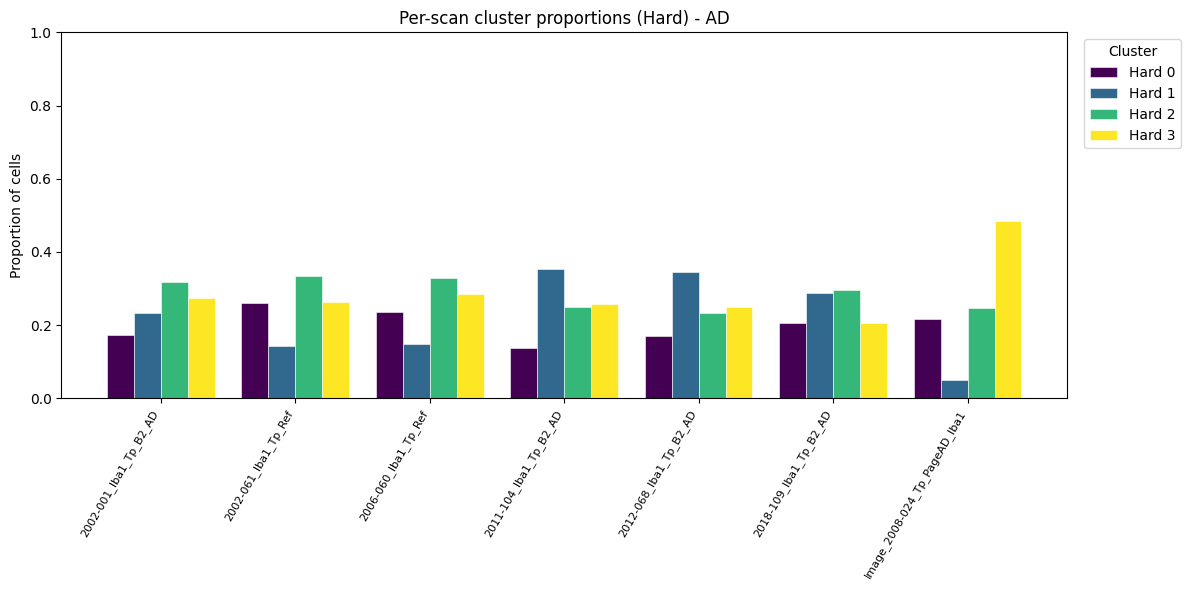

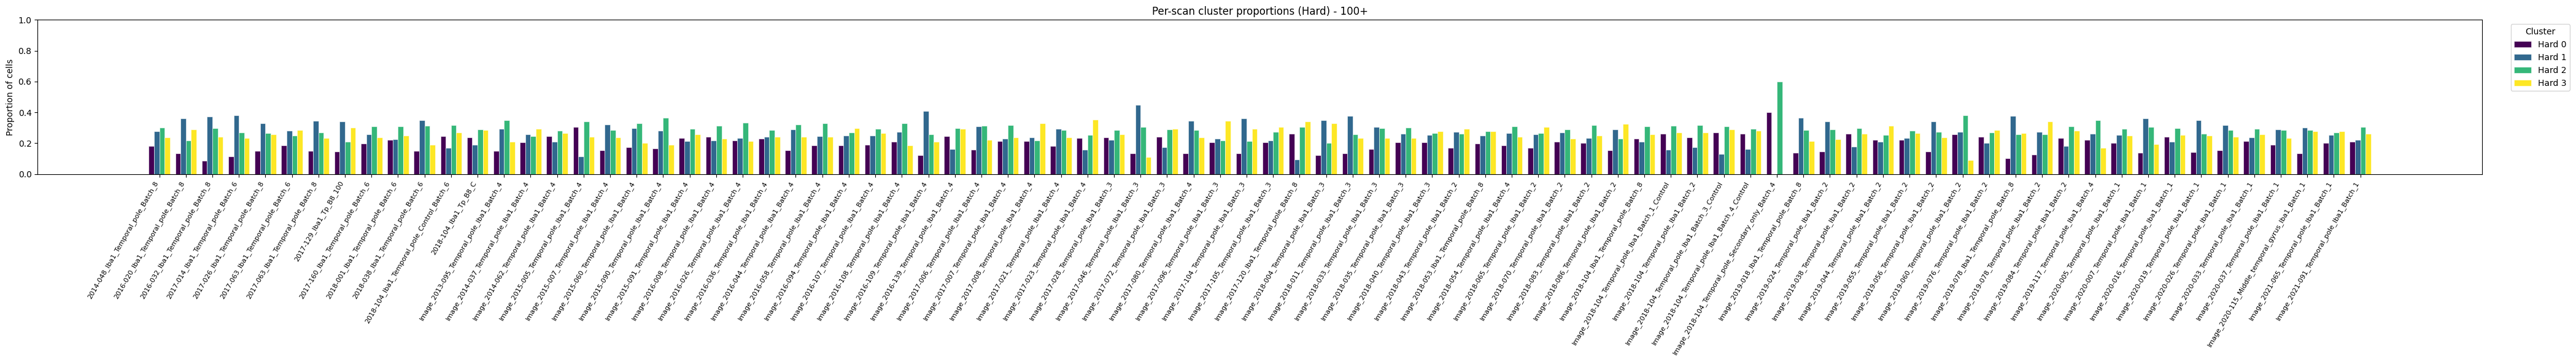

In [41]:
from analysis_utils import plot_cluster_distribution_per_scan, plot_tetrahedron_composition_interactive

plot_cluster_distribution_per_scan(
    final_cluster_props_df,
    cluster_type = 'hard'
)

# Example
plot_tetrahedron_composition_interactive(final_cluster_props_df, cluster_type="hard", diagnosis_col = 'diagnosis_group_pathology')

In [42]:
from statistical_tests import dirichlet_scan_level_group_comparison

hard_dirichlet_results = dirichlet_scan_level_group_comparison(
    final_cluster_props_df,
    cluster_type="hard",
    n_boot=1000,
    random_state=42,
)

soft_dirichlet_results = dirichlet_scan_level_group_comparison(
    final_cluster_props_df,
    cluster_type="soft",
    n_boot=1000,
    random_state=42,
)


=== Dirichlet fit summary (hard) ===
group  n_scans  alpha0_concentration  mean_entropy
   AD        7             30.098631      1.370745
 100+       84             11.225506      1.374201

=== Cluster mean differences (Dirichlet, bootstrap) ===
       cluster  delta_mean_AD_minus_100+   ci_2.5%  ci_97.5%  p_AD_gt_100+
hard_cluster_3                  0.057938 -0.005445  0.133549         0.953
hard_cluster_1                 -0.027404 -0.114226  0.068153         0.285
hard_cluster_2                 -0.020460 -0.073219  0.023904         0.269
hard_cluster_0                 -0.010074 -0.068709  0.038716         0.383

=== Cluster variance differences (Dirichlet-implied, bootstrap) ===
       cluster  delta_dirichlet_var_AD_minus_100+   ci_2.5%  ci_97.5%  p_AD_gt_100+
hard_cluster_2                          -0.010103 -0.034702  0.005916         0.306
hard_cluster_0                          -0.008244 -0.029686  0.005187         0.311
hard_cluster_1                          -0.007817 -0.0225

Pairwise Dirichlet analysis using pathology-aware diagnosis groups

In [43]:
pairwise_dirichlet_results = {'hard': {}, 'soft': {}}

for group_a, group_b in pairwise_group_comparisons:
    print(f'\n===== Dirichlet (hard): {group_a} vs {group_b} =====')
    pairwise_dirichlet_results['hard'][(group_a, group_b)] = dirichlet_scan_level_group_comparison(
        final_cluster_props_df,
        cluster_type='hard',
        diagnosis_col='diagnosis_group_pathology',
        scan_col='scan_name',
        group_a=group_a,
        group_b=group_b,
        n_boot=1000,
        random_state=42,
    )

    print(f'\n===== Dirichlet (soft): {group_a} vs {group_b} =====')
    pairwise_dirichlet_results['soft'][(group_a, group_b)] = dirichlet_scan_level_group_comparison(
        final_cluster_props_df,
        cluster_type='soft',
        diagnosis_col='diagnosis_group_pathology',
        scan_col='scan_name',
        group_a=group_a,
        group_b=group_b,
        n_boot=1000,
        random_state=42,
    )



===== Dirichlet (hard): AD vs 100+_with_pathology =====
=== Dirichlet fit summary (hard) ===
              group  n_scans  alpha0_concentration  mean_entropy
                 AD        7             30.098631      1.370745
100+_with_pathology       39             70.901608      1.373289

=== Cluster mean differences (Dirichlet, bootstrap) ===
       cluster  delta_mean_AD_minus_100+_with_pathology   ci_2.5%  ci_97.5%  p_AD_gt_100+_with_pathology
hard_cluster_1                                -0.064873 -0.143130  0.029970                        0.083
hard_cluster_3                                 0.041463 -0.010663  0.107320                        0.918
hard_cluster_0                                 0.020951 -0.017364  0.054724                        0.881
hard_cluster_2                                 0.002459 -0.026601  0.030297                        0.599

=== Cluster variance differences (Dirichlet-implied, bootstrap) ===
       cluster  delta_dirichlet_var_AD_minus_100+_with_patho

Dirichlet robustness

In [44]:
print(final_cluster_props_df.columns)

Index(['scan_name', 'diagnosis_group', 'diagnosis_group_pathology', 'n_cells',
       'hard_cluster_0', 'hard_cluster_1', 'hard_cluster_2', 'hard_cluster_3',
       'soft_cluster_0', 'soft_cluster_1', 'soft_cluster_2', 'soft_cluster_3'],
      dtype='object')


In [45]:
# Remove the bottom 10% of scans based on not enough cells
hard_dirichlet_results = dirichlet_scan_level_group_comparison(
    final_cluster_props_df,
    cluster_type="hard",
    n_boot=1000,
    random_state=42,
    remove_small_scans = True, 
    min_cells_per_scan_for_inclusion = None
)

Applied small-scan filter before Dirichlet: threshold=7098.0, removed_scans=9
=== Dirichlet fit summary (hard) ===
group  n_scans  alpha0_concentration  mean_entropy
   AD        5             53.293556      1.378248
 100+       77             72.615930      1.376520

=== Cluster mean differences (Dirichlet, bootstrap) ===
       cluster  delta_mean_AD_minus_100+   ci_2.5%  ci_97.5%  p_AD_gt_100+
hard_cluster_1                 -0.013533 -0.090549  0.075825         0.345
hard_cluster_0                  0.009178 -0.031154  0.047953         0.674
hard_cluster_3                  0.002812 -0.027513  0.025632         0.596
hard_cluster_2                  0.001543 -0.036229  0.035568         0.529

=== Cluster variance differences (Dirichlet-implied, bootstrap) ===
       cluster  delta_dirichlet_var_AD_minus_100+   ci_2.5%  ci_97.5%  p_AD_gt_100+
hard_cluster_2                           0.000355 -0.002414  0.001946         0.679
hard_cluster_3                           0.000354 -0.002223  0.

In [46]:
from statistical_tests import dirichlet_loocv_robustness_analysis

hard_dirichlet_loocv = dirichlet_loocv_robustness_analysis(
    full_df=final_cluster_props_df,
    cluster_type="hard",
    diagnosis_col="diagnosis_group_pathology",
    scan_col="scan_name",
    group_a="AD",
    group_b="100+_without_pathology",
    n_boot=1000,
    random_state=42,
    plot=True,
    verbose=False,
    only_check_ad = True, 
    significance_threshold = 0.9
)

# soft_dirichlet_loocv = dirichlet_loocv_robustness_analysis(
#     full_df=final_cluster_props_df,
#     cluster_type="soft",
#     diagnosis_col="diagnosis_group",
#     scan_col="scan_name",
#     group_a="AD",
#     group_b="100+",
#     n_boot=1000,
#     random_state=42,
#     plot=True,
#     verbose=False,
# )

# Optional quick access to summaries
hard_dirichlet_loocv_summary = hard_dirichlet_loocv["loocv_summary_df"]
# soft_dirichlet_loocv_summary = soft_dirichlet_loocv["loocv_summary_df"]


TypeError: dirichlet_loocv_robustness_analysis() got an unexpected keyword argument 'significance_threshold'

## Compositional Regression (Hard Clusters ~ Numeric Scan Features, LOOCV)

=== LOOCV Compositional Regression Performance (Hard Clusters) ===
N scans used: 90
Numeric scan features used: ['Aβ42_load', 'CERAD_score', 'AT8_load']
Overall MAE (LR): 5.592 percentage points
Overall MAE (predict-mean baseline): 4.238 percentage points
Overall improvement vs baseline: -1.354 percentage points
       cluster  mae_lr_percentage_points  mae_mean_baseline_percentage_points  improvement_vs_mean_percentage_points  relative_improvement_vs_mean_pct
hard_cluster_0                  4.626818                             4.077275                              -0.549543                        -13.478196
hard_cluster_1                  7.241337                             6.140264                              -1.101073                        -17.932006
hard_cluster_2                  5.288742                             2.972340                              -2.316401                        -77.931909
hard_cluster_3                  5.211975                             3.763578     

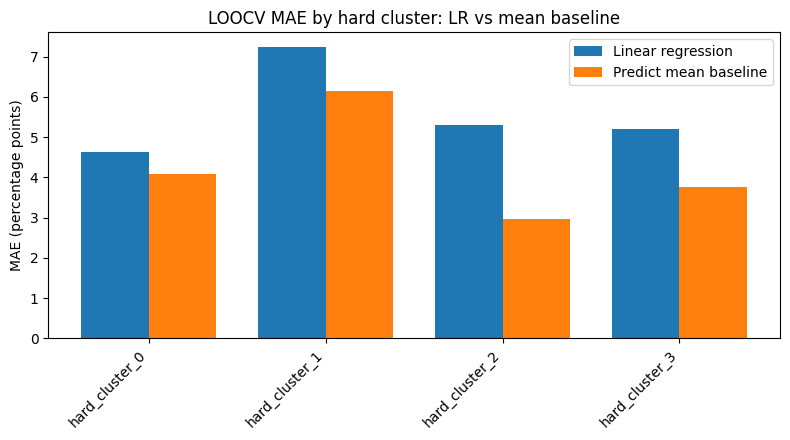

=== Mean LOOCV coefficients (standardized X, ALR targets) ===
                                  Aβ42_load  CERAD_score  AT8_load
hard_cluster_0_vs_hard_cluster_3   0.013851    -0.183414 -0.010744
hard_cluster_1_vs_hard_cluster_3   0.022089     0.051274 -0.088949
hard_cluster_2_vs_hard_cluster_3   0.015758    -0.186393 -0.035057


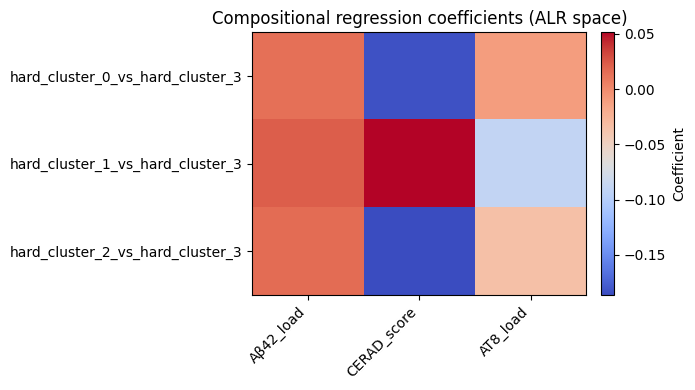

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Ensure df_scan_full exists (scan-level morphology + scan_features + cluster proportions).
if 'df_scan_full' not in globals():
    df_scan_full = df_summary_per_scan.merge(
        final_cluster_props_df,
        on='scan_name',
        how='inner',
        suffixes=('_summary', '_cluster'),
    )
    if {'diagnosis_group_summary', 'diagnosis_group_cluster'}.issubset(df_scan_full.columns):
        df_scan_full['diagnosis_group'] = df_scan_full['diagnosis_group_summary'].combine_first(df_scan_full['diagnosis_group_cluster'])
        df_scan_full = df_scan_full.drop(columns=['diagnosis_group_summary', 'diagnosis_group_cluster'])

hard_cols = sorted([c for c in df_scan_full.columns if c.startswith('hard_cluster_')], key=lambda x: int(x.split('_')[-1]))

# Choose which scan features to use as training inputs.
# Set to None to automatically use all numeric scan_features.
selected_training_features = ['Aβ42_load', 'CERAD_score', 'AT8_load']

if selected_training_features is None:
    numeric_scan_features = []
    for c in scan_features:
        if c in df_scan_full.columns and pd.api.types.is_numeric_dtype(df_scan_full[c]):
            numeric_scan_features.append(c)
else:
    missing_features = [c for c in selected_training_features if c not in df_scan_full.columns]
    if missing_features:
        raise ValueError(f'Missing selected training features in df_scan_full: {missing_features}')

    non_numeric_features = [
        c for c in selected_training_features
        if not pd.api.types.is_numeric_dtype(df_scan_full[c])
    ]
    if non_numeric_features:
        raise ValueError(f'Selected training features are not numeric: {non_numeric_features}')

    numeric_scan_features = selected_training_features.copy()

if not numeric_scan_features:
    raise ValueError('No numeric scan_features found in df_scan_full for compositional regression.')

work_cols = ['scan_name', 'diagnosis_group'] + numeric_scan_features + hard_cols
df_comp = df_scan_full[work_cols].copy()

# Coerce numerics and drop rows with missing model inputs.
for c in numeric_scan_features + hard_cols:
    df_comp[c] = pd.to_numeric(df_comp[c], errors='coerce')
df_comp = df_comp.dropna(subset=numeric_scan_features + hard_cols).copy()

# Helper transforms for compositional regression (ALR with last cluster as reference).
def alr_transform(Y, eps=1e-9):
    Yc = np.clip(Y, eps, 1.0)
    Yc = Yc / Yc.sum(axis=1, keepdims=True)
    ref = Yc[:, [-1]]
    return np.log(Yc[:, :-1] / ref)

def alr_inverse(Z):
    exp_z = np.exp(Z)
    denom = 1.0 + exp_z.sum(axis=1, keepdims=True)
    Y = np.concatenate([exp_z / denom, 1.0 / denom], axis=1)
    return Y

X = df_comp[numeric_scan_features].to_numpy(dtype=float)
Y = df_comp[hard_cols].to_numpy(dtype=float)
Y = Y / Y.sum(axis=1, keepdims=True)

loo = LeaveOneOut()
pred_rows = []
coef_list = []
intercept_list = []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    Z_train = alr_transform(Y_train)

    lr = LinearRegression()
    lr.fit(X_train_s, Z_train)

    Z_pred = lr.predict(X_test_s)
    Y_pred = alr_inverse(Z_pred)

    pred_rows.append({
        'test_index': int(test_idx[0]),
        'scan_name': df_comp.iloc[test_idx[0]]['scan_name'],
        'diagnosis_group': df_comp.iloc[test_idx[0]]['diagnosis_group'],
        'y_true': Y_test[0],
        'y_pred': Y_pred[0],
    })

    coef_list.append(lr.coef_)      # shape: (n_clusters-1, n_features)
    intercept_list.append(lr.intercept_)

# Collect predictions
Y_true = np.vstack([r['y_true'] for r in pred_rows])
Y_pred = np.vstack([r['y_pred'] for r in pred_rows])

# Performance in percentage points (pp)
# Compare LR vs a naive baseline that always predicts the training-set mean composition.
abs_err_lr = np.abs(Y_pred - Y_true)
mae_overall_pp = 100.0 * abs_err_lr.mean()
mae_per_cluster_pp = 100.0 * abs_err_lr.mean(axis=0)

# Baseline predictions aligned with LOOCV folds (predict mean cluster proportion from train fold).
Y_pred_mean = []
for train_idx, test_idx in loo.split(X):
    Y_train = Y[train_idx]
    mean_pred = Y_train.mean(axis=0, keepdims=True)
    Y_pred_mean.append(mean_pred[0])
Y_pred_mean = np.vstack(Y_pred_mean)
abs_err_mean = np.abs(Y_pred_mean - Y_true)
mae_mean_per_cluster_pp = 100.0 * abs_err_mean.mean(axis=0)
mae_mean_overall_pp = 100.0 * abs_err_mean.mean()

perf_df = pd.DataFrame({
    'cluster': hard_cols,
    'mae_lr_percentage_points': mae_per_cluster_pp,
    'mae_mean_baseline_percentage_points': mae_mean_per_cluster_pp,
})
perf_df['improvement_vs_mean_percentage_points'] = perf_df['mae_mean_baseline_percentage_points'] - perf_df['mae_lr_percentage_points']
perf_df['relative_improvement_vs_mean_pct'] = 100.0 * perf_df['improvement_vs_mean_percentage_points'] / perf_df['mae_mean_baseline_percentage_points'].replace(0, np.nan)

print('=== LOOCV Compositional Regression Performance (Hard Clusters) ===')
print(f'N scans used: {len(df_comp)}')
print(f'Numeric scan features used: {numeric_scan_features}')
print(f'Overall MAE (LR): {mae_overall_pp:.3f} percentage points')
print(f'Overall MAE (predict-mean baseline): {mae_mean_overall_pp:.3f} percentage points')
print(f'Overall improvement vs baseline: {(mae_mean_overall_pp - mae_overall_pp):.3f} percentage points')
print(perf_df.to_string(index=False))

# Plot: per-cluster MAE comparison (LR vs mean baseline)
x = np.arange(len(perf_df))
w = 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(x - w/2, perf_df['mae_lr_percentage_points'], width=w, label='Linear regression')
plt.bar(x + w/2, perf_df['mae_mean_baseline_percentage_points'], width=w, label='Predict mean baseline')
plt.xticks(x, perf_df['cluster'], rotation=45, ha='right')
plt.ylabel('MAE (percentage points)')
plt.title('LOOCV MAE by hard cluster: LR vs mean baseline')
plt.legend()
plt.tight_layout()
plt.show()

# Aggregate coefficients across LOOCV folds for interpretability.
coef_mean = np.mean(np.stack(coef_list, axis=0), axis=0)
# coef_mean shape: (n_clusters - 1, n_features), ALR targets use last cluster as reference.
alr_targets = [f'{c}_vs_{hard_cols[-1]}' for c in hard_cols[:-1]]
coef_df = pd.DataFrame(coef_mean, index=alr_targets, columns=numeric_scan_features)

print('=== Mean LOOCV coefficients (standardized X, ALR targets) ===')
print(coef_df.to_string())

# Plot: coefficient heatmap
plt.figure(figsize=(max(7, len(numeric_scan_features) * 0.8), 4))
im = plt.imshow(coef_df.values, cmap='coolwarm', aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Coefficient')
plt.xticks(np.arange(len(numeric_scan_features)), numeric_scan_features, rotation=45, ha='right')
plt.yticks(np.arange(len(alr_targets)), alr_targets)
plt.title('Compositional regression coefficients (ALR space)')
plt.tight_layout()
plt.show()

# Optional: save main outputs for reuse
compositional_regression_results = {
    'df_used': df_comp,
    'performance_by_cluster': perf_df,
    'overall_mae_lr_percentage_points': mae_overall_pp,
    'overall_mae_mean_baseline_percentage_points': mae_mean_overall_pp,
    'coefficients_alr': coef_df,
    'predictions': pd.DataFrame({
        'scan_name': [r['scan_name'] for r in pred_rows],
        'diagnosis_group': [r['diagnosis_group'] for r in pred_rows],
    }),
}


## Per-Cluster Linear Regression (One Model Per Hard Cluster, LOOCV)

=== LOOCV Per-Cluster Linear Regression Performance (Hard Clusters) ===
N scans used: 90
Numeric scan features used: ['Aβ42_load', 'CERAD_score', 'AT8_load']
Overall MAE (LR): 4.401 percentage points
Overall MAE (predict-mean baseline): 4.238 percentage points
Overall improvement vs baseline: -0.163 percentage points
       cluster  mae_lr_percentage_points  mae_mean_baseline_percentage_points  improvement_vs_mean_percentage_points
hard_cluster_0                  4.190266                             4.077275                              -0.112992
hard_cluster_1                  6.299120                             6.140264                              -0.158855
hard_cluster_2                  3.090638                             2.972340                              -0.118297
hard_cluster_3                  4.023488                             3.763578                              -0.259910


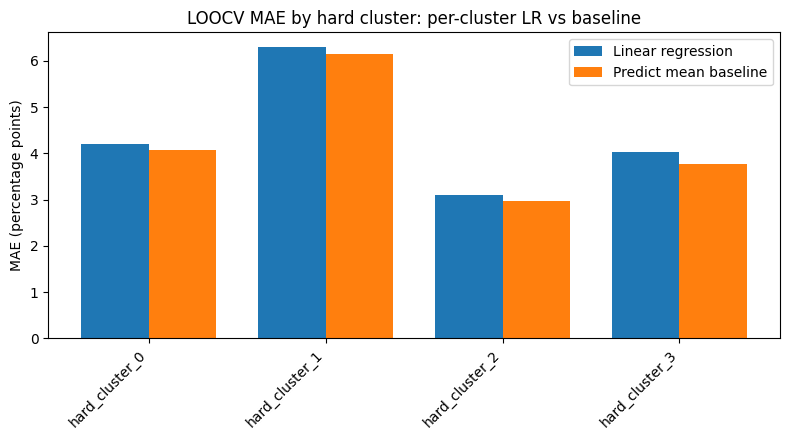

=== Mean LOOCV coefficients (standardized X, one model per cluster) ===
                Aβ42_load  CERAD_score  AT8_load
hard_cluster_0   0.001440    -0.003497  0.003009
hard_cluster_1   0.001037     0.008028 -0.009126
hard_cluster_2   0.002671    -0.004491 -0.001829
hard_cluster_3  -0.005148    -0.000040  0.007947


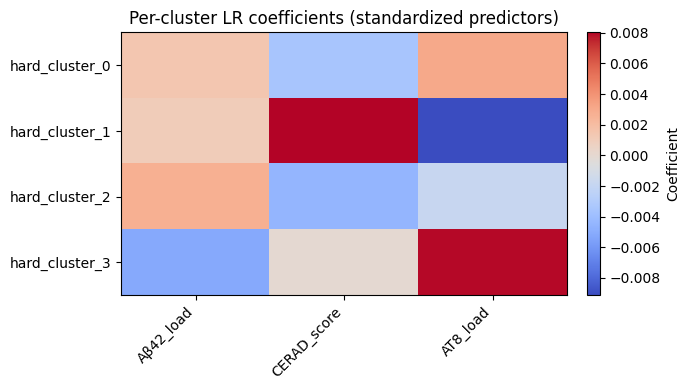

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

if 'df_scan_full' not in globals():
    df_scan_full = df_summary_per_scan.merge(
        final_cluster_props_df,
        on='scan_name',
        how='inner',
        suffixes=('_summary', '_cluster'),
    )
    if {'diagnosis_group_summary', 'diagnosis_group_cluster'}.issubset(df_scan_full.columns):
        df_scan_full['diagnosis_group'] = df_scan_full['diagnosis_group_summary'].combine_first(df_scan_full['diagnosis_group_cluster'])
        df_scan_full = df_scan_full.drop(columns=['diagnosis_group_summary', 'diagnosis_group_cluster'])

hard_cols = sorted([c for c in df_scan_full.columns if c.startswith('hard_cluster_')], key=lambda x: int(x.split('_')[-1]))

# Set this list to control which scan features are used as model inputs.
selected_training_features = ['Aβ42_load', 'CERAD_score', 'AT8_load']

missing_features = [c for c in selected_training_features if c not in df_scan_full.columns]
if missing_features:
    raise ValueError(f'Missing selected training features in df_scan_full: {missing_features}')

non_numeric_features = [c for c in selected_training_features if not pd.api.types.is_numeric_dtype(df_scan_full[c])]
if non_numeric_features:
    raise ValueError(f'Selected training features are not numeric: {non_numeric_features}')

numeric_scan_features = selected_training_features.copy()

work_cols = ['scan_name', 'diagnosis_group'] + numeric_scan_features + hard_cols
df_pc = df_scan_full[work_cols].copy()
for c in numeric_scan_features + hard_cols:
    df_pc[c] = pd.to_numeric(df_pc[c], errors='coerce')
df_pc = df_pc.dropna(subset=numeric_scan_features + hard_cols).copy()

X = df_pc[numeric_scan_features].to_numpy(dtype=float)
Y = df_pc[hard_cols].to_numpy(dtype=float)
Y = Y / Y.sum(axis=1, keepdims=True)

loo = LeaveOneOut()
pred_lr = np.zeros_like(Y, dtype=float)
pred_mean = np.zeros_like(Y, dtype=float)
coef_folds = {c: [] for c in hard_cols}

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train = Y[train_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    pred_mean[test_idx[0], :] = Y_train.mean(axis=0)

    for j, cl in enumerate(hard_cols):
        lr = LinearRegression()
        lr.fit(X_train_s, Y_train[:, j])
        pred_lr[test_idx[0], j] = lr.predict(X_test_s)[0]
        coef_folds[cl].append(lr.coef_)

pred_lr = np.clip(pred_lr, 0.0, 1.0)

abs_err_lr = np.abs(pred_lr - Y)
abs_err_mean = np.abs(pred_mean - Y)

mae_lr_pp = 100.0 * abs_err_lr.mean(axis=0)
mae_mean_pp = 100.0 * abs_err_mean.mean(axis=0)
overall_mae_lr_pp = 100.0 * abs_err_lr.mean()
overall_mae_mean_pp = 100.0 * abs_err_mean.mean()

perf_df_pc = pd.DataFrame({
    'cluster': hard_cols,
    'mae_lr_percentage_points': mae_lr_pp,
    'mae_mean_baseline_percentage_points': mae_mean_pp,
})
perf_df_pc['improvement_vs_mean_percentage_points'] = perf_df_pc['mae_mean_baseline_percentage_points'] - perf_df_pc['mae_lr_percentage_points']

print('=== LOOCV Per-Cluster Linear Regression Performance (Hard Clusters) ===')
print(f'N scans used: {len(df_pc)}')
print(f'Numeric scan features used: {numeric_scan_features}')
print(f'Overall MAE (LR): {overall_mae_lr_pp:.3f} percentage points')
print(f'Overall MAE (predict-mean baseline): {overall_mae_mean_pp:.3f} percentage points')
print(f'Overall improvement vs baseline: {(overall_mae_mean_pp - overall_mae_lr_pp):.3f} percentage points')
print(perf_df_pc.to_string(index=False))

x = np.arange(len(perf_df_pc))
w = 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(x - w/2, perf_df_pc['mae_lr_percentage_points'], width=w, label='Linear regression')
plt.bar(x + w/2, perf_df_pc['mae_mean_baseline_percentage_points'], width=w, label='Predict mean baseline')
plt.xticks(x, perf_df_pc['cluster'], rotation=45, ha='right')
plt.ylabel('MAE (percentage points)')
plt.title('LOOCV MAE by hard cluster: per-cluster LR vs baseline')
plt.legend()
plt.tight_layout()
plt.show()

coef_mean_pc_df = pd.DataFrame(
    {cl: np.mean(np.vstack(coef_folds[cl]), axis=0) for cl in hard_cols},
    index=numeric_scan_features,
).T

print('=== Mean LOOCV coefficients (standardized X, one model per cluster) ===')
print(coef_mean_pc_df.to_string())

plt.figure(figsize=(max(7, len(numeric_scan_features) * 0.8), 4))
im = plt.imshow(coef_mean_pc_df.values, cmap='coolwarm', aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Coefficient')
plt.xticks(np.arange(len(numeric_scan_features)), numeric_scan_features, rotation=45, ha='right')
plt.yticks(np.arange(len(hard_cols)), hard_cols)
plt.title('Per-cluster LR coefficients (standardized predictors)')
plt.tight_layout()
plt.show()

per_cluster_lr_results = {
    'df_used': df_pc,
    'performance_by_cluster': perf_df_pc,
    'overall_mae_lr_percentage_points': overall_mae_lr_pp,
    'overall_mae_mean_baseline_percentage_points': overall_mae_mean_pp,
    'coefficients': coef_mean_pc_df,
}


## Correlation Matrix: Cluster Proportions vs Scan Features

=== Spearman correlation: cluster proportions vs numeric scan features ===
                Age_at_death  Braak_NFT_stage  CERAD_score  Aβ load_total  Aβ40_load  Aβ42_load  AT8_load  pTau217_load  GT38_load
hard_cluster_0     -0.036517         0.056139    -0.018763       0.058132  -0.038716   0.030089 -0.028031      0.063293   0.132817
hard_cluster_1     -0.000632        -0.046614     0.071641       0.014944   0.089475   0.008919  0.078950      0.004596  -0.066220
hard_cluster_2      0.033053        -0.009575    -0.116250       0.017593  -0.173306  -0.034770 -0.096779     -0.084793  -0.134063
hard_cluster_3      0.043218        -0.027294    -0.047881      -0.124976   0.002850  -0.042821 -0.063642     -0.070928   0.032374
soft_cluster_0     -0.043586         0.078640    -0.004389       0.060790  -0.020000   0.038196 -0.004710      0.077582   0.149919
soft_cluster_1      0.020812        -0.035168     0.081287       0.024526   0.106832   0.020849  0.096751      0.019443  -0.044011
soft_clu

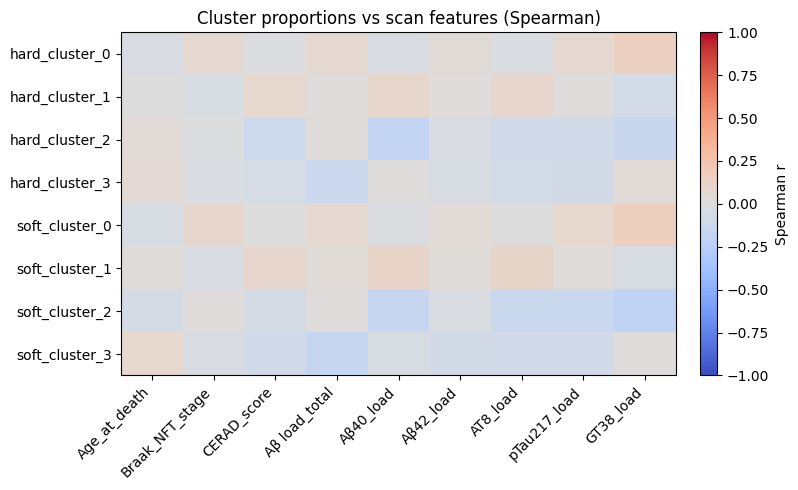

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df_scan_full exists
if 'df_scan_full' not in globals():
    df_scan_full = df_summary_per_scan.merge(
        final_cluster_props_df,
        on='scan_name',
        how='inner',
        suffixes=('_summary', '_cluster'),
    )
    if {'diagnosis_group_summary', 'diagnosis_group_cluster'}.issubset(df_scan_full.columns):
        df_scan_full['diagnosis_group'] = df_scan_full['diagnosis_group_summary'].combine_first(df_scan_full['diagnosis_group_cluster'])
        df_scan_full = df_scan_full.drop(columns=['diagnosis_group_summary', 'diagnosis_group_cluster'])

cluster_cols = sorted(
    [c for c in df_scan_full.columns if c.startswith('hard_cluster_') or c.startswith('soft_cluster_')],
    key=lambda x: (0 if x.startswith('hard_cluster_') else 1, int(x.split('_')[-1]))
)

numeric_scan_features = [
    c for c in scan_features
    if c in df_scan_full.columns and pd.api.types.is_numeric_dtype(df_scan_full[c])
]

if not numeric_scan_features:
    raise ValueError('No numeric scan_features found for correlation analysis.')
if not cluster_cols:
    raise ValueError('No cluster proportion columns found in df_scan_full.')

corr_input = df_scan_full[numeric_scan_features + cluster_cols].copy()
for c in corr_input.columns:
    corr_input[c] = pd.to_numeric(corr_input[c], errors='coerce')
corr_input = corr_input.dropna()

cluster_vs_scan_corr = corr_input[numeric_scan_features + cluster_cols].corr(method='spearman').loc[cluster_cols, numeric_scan_features]

print('=== Spearman correlation: cluster proportions vs numeric scan features ===')
print(cluster_vs_scan_corr.to_string())

plt.figure(figsize=(max(8, len(numeric_scan_features) * 0.9), max(5, len(cluster_cols) * 0.5)))
im = plt.imshow(cluster_vs_scan_corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Spearman r')
plt.xticks(np.arange(len(numeric_scan_features)), numeric_scan_features, rotation=45, ha='right')
plt.yticks(np.arange(len(cluster_cols)), cluster_cols)
plt.title('Cluster proportions vs scan features (Spearman)')
plt.tight_layout()
plt.show()

cluster_scanfeature_correlation_results = cluster_vs_scan_corr
